<a href="https://colab.research.google.com/github/KyryloKozlovskyi/garbage-classification/blob/main/garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Garbage Image Classification with CNNs

**Student Name:** Kyrylo Kozlovskyi  
**Student ID:** G00425385  
**Module:** Machine Learning Technologies

**Seed:** 425385  
**Dataset:** Garbage (10 categories, 384x384, RGB)

---

## 1. Environment Setup & Utility Functions

### 1.1 Environment Setup

All required libraries are imported at the start of the notebook. TensorFlow serves as the deep learning framework, while scikit-learn provides evaluation metrics. The random seed is derived from the student ID (G00425385 becomes 425385) to ensure reproducibility of all data splits and model initialisation.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os, time, timeit, zipfile

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16

# Evaluation metrics from scikit-learn
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# Set global seed for reproducibility (student ID without G and leading zeros)
SEED = 425385
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow: {tf.__version__}')
gpu_devices = tf.config.list_physical_devices('GPU')
print(f'GPU detected: {bool(gpu_devices)}  {gpu_devices}')

TensorFlow: 2.20.0
GPU detected: True  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2 Utility Functions

The following helper functions are defined for reuse throughout the notebook. `show_curves` plots training and validation accuracy and loss side by side, which is essential for diagnosing overfitting and underfitting. `report_metrics` computes accuracy, macro F1, and a full per-class classification report. `show_confusion` displays a labelled confusion matrix. `measure_inference` uses `timeit` to measure prediction speed, as required by the project brief.

In [2]:
def show_curves(hist, title=''):
    """Side-by-side accuracy and loss plots from a Keras History object.
    A growing gap between train and val curves indicates overfitting.
    If both curves are low and close together, the model is underfitting."""
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    if title:
        fig.suptitle(title, fontsize=13)

    a1.plot(hist.history['accuracy'],     label='train')
    a1.plot(hist.history['val_accuracy'],  label='val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
    a1.legend(); a1.grid(True, alpha=0.3)

    a2.plot(hist.history['loss'],     label='train')
    a2.plot(hist.history['val_loss'],  label='val')
    a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
    a2.legend(); a2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def get_predictions(model, dataset):
    """Return ground-truth and predicted label arrays for a dataset."""
    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        logits = model.predict(imgs, verbose=0)
        y_true.append(lbls.numpy())
        y_pred.append(np.argmax(logits, axis=1))  # pick highest-scoring class
    return np.concatenate(y_true), np.concatenate(y_pred)


def report_metrics(model, dataset, tag='Validation'):
    """Print accuracy, macro-F1, per-class report, and return predictions.
    Macro F1 is the primary metric because it treats all classes equally
    regardless of how many samples each class has."""
    y_true, y_pred = get_predictions(model, dataset)

    acc  = np.mean(y_true == y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')

    print(f'\n=== {tag} ===')
    print(f'Accuracy :  {acc:.4f}')
    print(f'Macro F1 :  {mf1:.4f}')
    print(f'Parameters: {model.count_params():,}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=label_names))
    return y_true, y_pred, mf1


def show_confusion(y_true, y_pred, title=''):
    """Display a labelled confusion matrix.
    Off-diagonal entries show which categories the model confuses."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap='Oranges', xticks_rotation=45)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


def measure_inference(model, dataset, n_runs=10):
    """Average inference time over n_runs using timeit on one batch.
    The spec requires timeit for inference measurements."""
    one_batch = next(iter(dataset))[0]
    t = timeit.timeit(
        lambda: model.predict(one_batch, verbose=0),
        number=n_runs
    ) / n_runs
    print(f'Mean inference time (1 batch, {n_runs} runs): {t:.4f} s')
    return t

---

## 2. Dataset Preparation

The dataset is stored as a zip file on Google Drive. To avoid slow I/O from reading directly off Drive during training, it is extracted to Colab's local disk before any processing begins.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Path config
ZIP_FILE = '/content/drive/MyDrive/garbage.zip'
LOCAL_DIR = '/content/garbage_dataset'

if not os.path.exists(ZIP_FILE):
    print(f'ERROR: {ZIP_FILE} not found.')
    print('Contents of Drive root:')
    for f in sorted(os.listdir('/content/drive/MyDrive'))[:15]:
        print(f'  {f}')
else:
    mb = os.path.getsize(ZIP_FILE) / 1024**2
    print(f'Zip found: {ZIP_FILE} ({mb:.0f} MB)')

Zip found: /content/drive/MyDrive/garbage.zip (390 MB)


In [5]:
# Extract once to local disk
if not os.path.exists(LOCAL_DIR):
    print('Extracting ...')
    with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
        zf.extractall(LOCAL_DIR)
    print('Extraction complete.')
else:
    print('Already extracted.')

Extracting ...
Extraction complete.


In [6]:
# Locate the folder that holds the 10 class sub-directories
TARGET_CLASSES = {
    'battery', 'biological', 'cardboard', 'clothes', 'glass',
    'metal', 'paper', 'plastic', 'shoes', 'trash'
}

DATA_ROOT = None
for dirpath, dirnames, _ in os.walk(LOCAL_DIR):
    if TARGET_CLASSES.issubset(set(dirnames)):
        DATA_ROOT = dirpath
        break

if DATA_ROOT:
    print(f'Dataset root: {DATA_ROOT}')
else:
    print('Could not auto-detect.')

Dataset root: /content/garbage_dataset/garbage


---

## 3. Exploratory Data Analysis

### 3.1 Class Distribution

Before any modelling, the class distribution was inspected. If certain categories have significantly fewer images than others, accuracy becomes a misleading metric because a model that simply predicts the majority class can score well while being useless for rare categories. For this reason, macro-averaged F1 score is used as the primary comparison metric throughout this work, as it weights all classes equally regardless of their size.

In [7]:
# Count the number of image files in each class folder
# This gives the full dataset distribution before any splitting
categories = sorted(
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
)

img_counts = {}
for cat in categories:
    folder = os.path.join(DATA_ROOT, cat)
    n = len([f for f in os.listdir(folder) if not f.startswith('.')])
    img_counts[cat] = n

total = sum(img_counts.values())
largest = max(img_counts, key=img_counts.get)
smallest = min(img_counts, key=img_counts.get)

# Print sorted by count (descending) for easy reading
print(f'{"Category":<14} {"Count":>6}')
print('-' * 22)
for cat, n in sorted(img_counts.items(), key=lambda x: -x[1]):
    print(f'{cat:<14} {n:>6}')
print('-' * 22)
print(f'{"Total":<14} {total:>6}')
print()
print(f'Largest:  {largest} ({img_counts[largest]})')
print(f'Smallest: {smallest} ({img_counts[smallest]})')
# Imbalance ratio shows how skewed the dataset is
print(f'Ratio:    {img_counts[largest] / img_counts[smallest]:.1f}x')

Category        Count
----------------------
clothes          1892
glass            1736
plastic          1597
shoes            1449
cardboard        1411
paper            1336
metal             930
battery           756
biological        699
trash             453
----------------------
Total           12259

Largest:  clothes (1892)
Smallest: trash (453)
Ratio:    4.2x


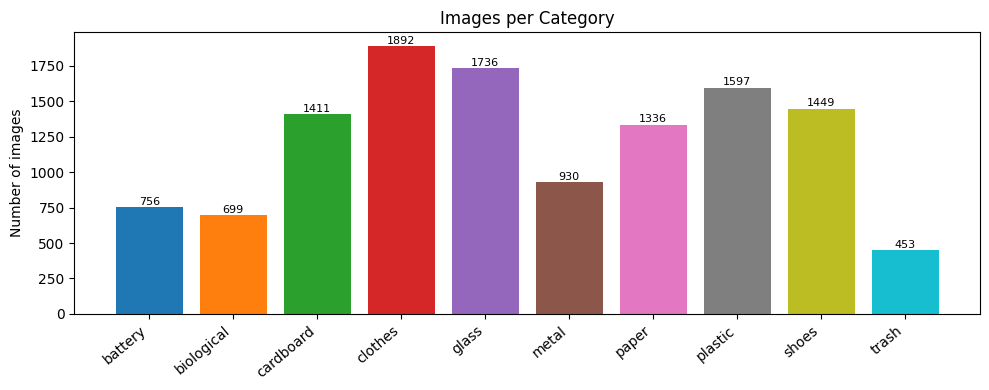

In [8]:
# Visualise the distribution
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(img_counts.keys(), img_counts.values(),
              color=plt.cm.tab10.colors[:len(img_counts)])

for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 15,
            int(b.get_height()), ha='center', fontsize=8)

ax.set_ylabel('Number of images')
ax.set_title('Images per Category')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Sample Images

A selection of images from each class was visualised to develop an understanding of the visual variation within and between categories, and to identify which classes might be visually similar to one another.

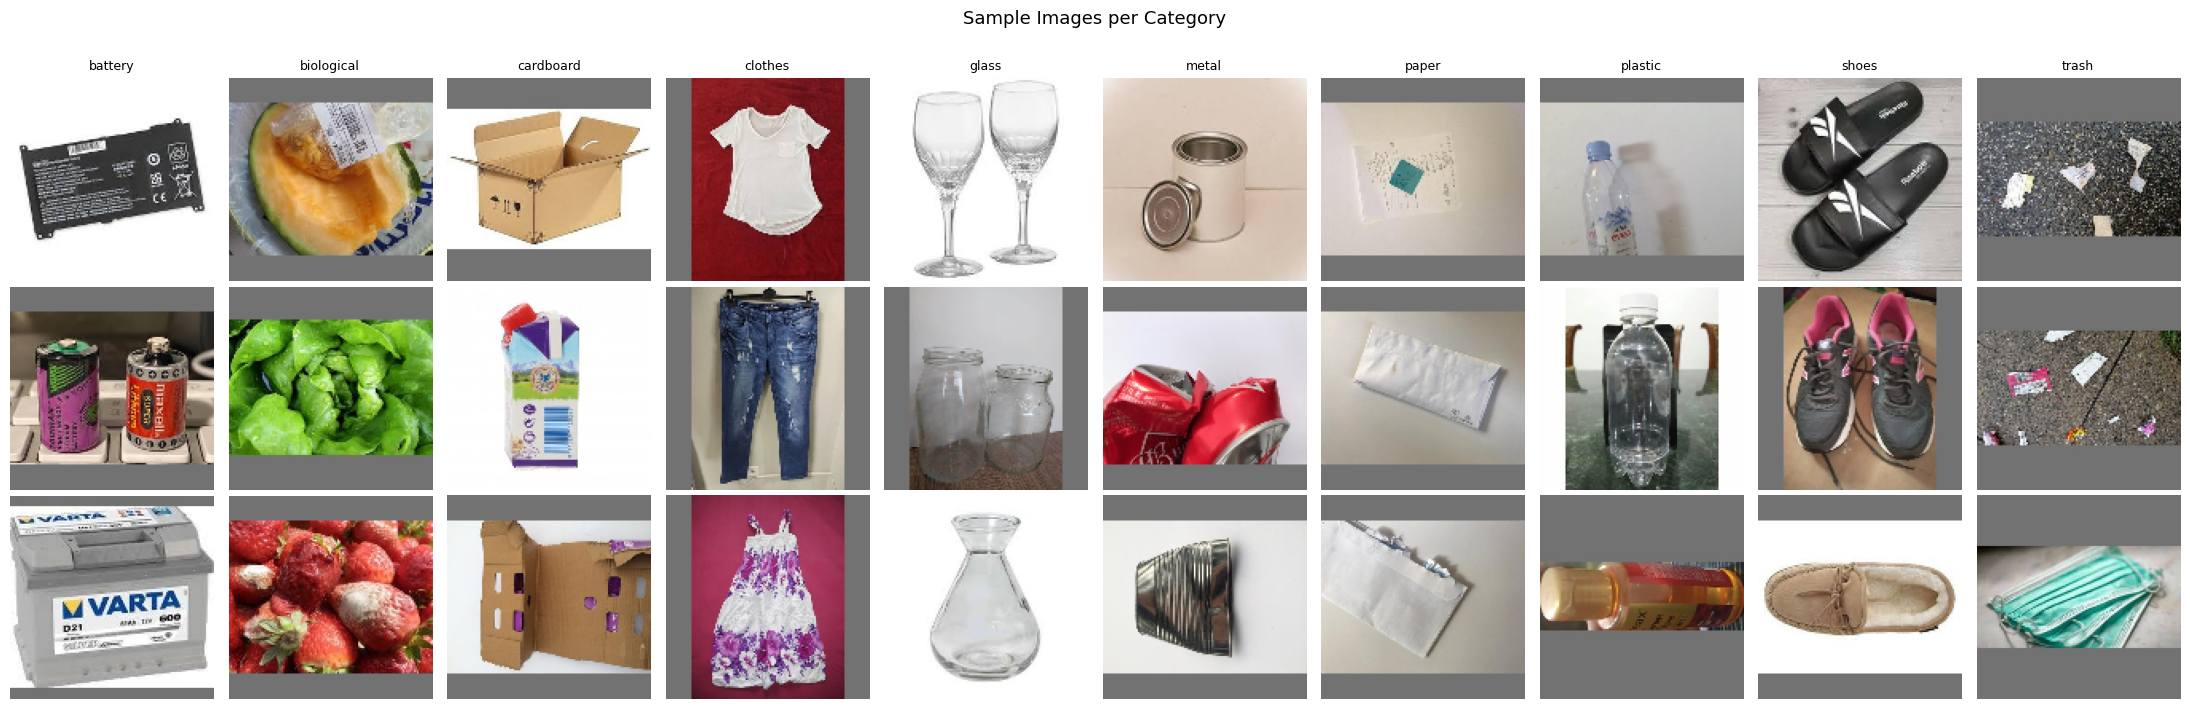

In [9]:
n_show = 3  # images per class
fig, axes = plt.subplots(n_show, len(categories), figsize=(22, 7))

for col_idx, cat in enumerate(categories):
    folder = os.path.join(DATA_ROOT, cat)
    samples = sorted(os.listdir(folder))[:n_show]
    for row_idx, fname in enumerate(samples):
        img = tf.keras.utils.load_img(
            os.path.join(folder, fname), target_size=(128, 128)
        )
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
    axes[0, col_idx].set_title(cat, fontsize=9)

fig.suptitle('Sample Images per Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Image Dimensions and Pixel Values

The original image dimensions and pixel value range were verified to ensure consistency across the dataset and to confirm the expected input format for the models.

In [10]:
# Sample a few images per class to check dimensions
shapes_seen = set()
px_lo, px_hi = 255, 0

for cat in categories:
    folder = os.path.join(DATA_ROOT, cat)
    for fname in sorted(os.listdir(folder))[:5]:
        arr = np.array(
            tf.keras.utils.load_img(os.path.join(folder, fname))
        )
        shapes_seen.add(arr.shape)
        px_lo = min(px_lo, arr.min())
        px_hi = max(px_hi, arr.max())

print(f'Unique shapes found: {shapes_seen}')
print(f'Pixel range: [{px_lo}, {px_hi}]')

Unique shapes found: {(384, 384, 3)}
Pixel range: [0, 255]


---

## 4. Data Loading and Splitting

The images were loaded directly from the class-organised directory structure and split into three subsets: 70% training, 10% validation, and 20% test. Since the loading utility only supports a single split parameter, a 70/30 split was performed first, then the 30% holdout was divided into one-third validation and two-thirds test.

The **validation set** is used throughout to compare models and tune hyperparameters. The **test set** is held back for a single final evaluation of the chosen model and is never used for model selection.

In [11]:
# Hyperparameters
IMG_H = 128
IMG_W = 128
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

In [12]:
# First split: 70% training, 30% holdout
# The seed ensures the same images end up in each split every time
ds_train = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    label_mode='int'
)

# Get the 30% holdout for further splitting
ds_holdout = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    label_mode='int'
)

# Second split: divide the 30% holdout into validation (~10%) and test (~20%)
# Validation is used for model selection; test is used only once at the end
holdout_size = tf.data.experimental.cardinality(ds_holdout).numpy()
n_val = holdout_size // 3

ds_val = ds_holdout.take(n_val)
ds_test = ds_holdout.skip(n_val)

label_names = ds_train.class_names
n_classes = len(label_names)

print(f'Labels ({n_classes}): {label_names}')
print(f'Batches  train: {tf.data.experimental.cardinality(ds_train).numpy()}, '
      f'val: {tf.data.experimental.cardinality(ds_val).numpy()}, '
      f'test: {tf.data.experimental.cardinality(ds_test).numpy()}')

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
Labels (10): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Batches  train: 269, val: 38, test: 77


In [13]:
# Verify split sizes
n_train = sum(labels.shape[0] for _, labels in ds_train)
n_val_img = sum(labels.shape[0] for _, labels in ds_val)
n_test = sum(labels.shape[0] for _, labels in ds_test)

print(f'Images - train: {n_train}, val: {n_val_img}, test: {n_test}')
print(f'Total: {n_train + n_val_img + n_test}')

Images - train: 8582, val: 1216, test: 2461
Total: 12259


In [14]:
# Sanity check: shape and range of one batch
for batch_imgs, batch_labels in ds_train.take(1):
    print(f'Image batch: {batch_imgs.shape}  dtype={batch_imgs.dtype}')
    print(f'Label batch: {batch_labels.shape}  dtype={batch_labels.dtype}')
    print(f'Pixel range: [{batch_imgs.numpy().min():.0f}, {batch_imgs.numpy().max():.0f}]')

Image batch: (32, 128, 128, 3)  dtype=<dtype: 'float32'>
Label batch: (32,)  dtype=<dtype: 'int32'>
Pixel range: [0, 255]


### 4.1 Class Weights

To compensate for the imbalanced class distribution, class weights were computed so that misclassifying an underrepresented category is penalised more heavily during training. Classes with fewer images receive proportionally higher weights. For example, if one category has half as many samples as another, its misclassification penalty is roughly doubled. These weights are applied during every training run to prevent the model from being biased toward majority classes.

In [15]:
# Gather all training labels to compute class weights
# This iterates through the dataset once to collect every label
all_train_labels = np.concatenate(
    [labels.numpy() for _, labels in ds_train]
)

# 'balanced' mode sets weights inversely proportional to class frequency
# Rare classes (e.g. trash) get higher weights, common ones (e.g. clothes) lower
cw = compute_class_weight(
    'balanced',
    classes=np.arange(n_classes),
    y=all_train_labels
)
class_weights = {i: w for i, w in enumerate(cw)}

print(f'{"Class":<14} {"Weight":>8}')
print('-' * 24)
for i, name in enumerate(label_names):
    print(f'{name:<14} {class_weights[i]:>8.4f}')

Class            Weight
------------------------
battery          1.5718
biological       1.7130
cardboard        0.8642
clothes          0.6571
glass            0.6910
metal            1.3451
paper            0.9525
plastic          0.7711
shoes            0.8284
trash            2.8046


### 4.2 Performance Optimisation

Prefetching was applied to all data pipelines so that the next batch of images is prepared while the GPU processes the current one, reducing idle time between training steps.

In [16]:
ds_train = ds_train.prefetch(AUTOTUNE)
ds_val   = ds_val.prefetch(AUTOTUNE)
ds_test  = ds_test.prefetch(AUTOTUNE)

---

## 5. Data Augmentation

Data augmentation generates modified versions of each training image on every epoch through random horizontal flips, rotations, zooms, and brightness adjustments. This forces the model to learn general features rather than memorising specific training images, which helps reduce overfitting.

The augmentation layer is placed inside the model architecture so that transformations are applied only during training and automatically disabled during inference.

In [17]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
])

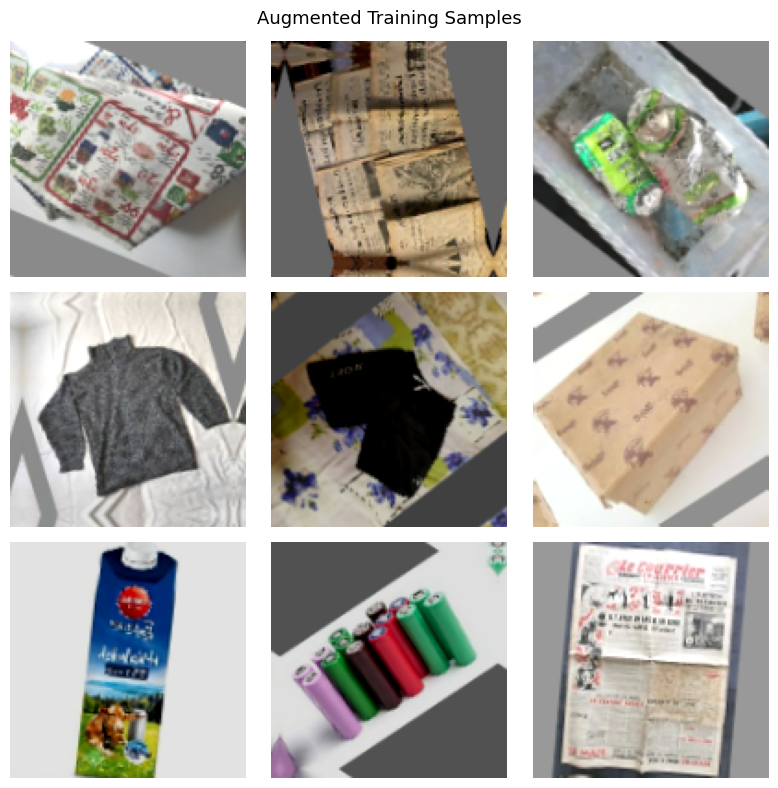

In [18]:
# Preview what the augmented images look like
# Each run produces different augmentations since they are random
sample_batch = next(iter(ds_train))[0][:9]  # grab 9 images

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    # Apply augmentation to a single image
    augmented = augmentation(tf.expand_dims(sample_batch[i], 0))
    ax.imshow(augmented[0].numpy().astype('uint8'))
    ax.axis('off')
fig.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. CNN from Scratch (RGB, 128x128)

### 6.1 Baseline Model

The initial model uses three convolutional blocks with increasing filter counts (16, 32, 64), each followed by max pooling. A rescaling layer normalises pixel values from [0, 255] to [0, 1] before they enter the convolutional layers. The classifier head uses global average pooling followed by a dense layer with 128 units.

The output layer produces raw scores (logits) with no activation function. The loss function handles the conversion internally, which is numerically more stable than applying softmax as a separate layer. No regularisation is applied in this baseline so that the raw capacity of the architecture can be assessed.

In [19]:
# Baseline RGB CNN following the same pattern from the beans lab:
# Three convolutional blocks (16, 32, 64 filters) with max pooling
# No dropout or regularisation (starting point for diagnosis)
rgb_baseline = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,                          # only active during training
    layers.Rescaling(1./255),              # normalise pixels to [0, 1]

    # Block 1 - detect low-level features (edges, simple textures)
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 2 - combine low-level features into mid-level patterns
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 3 - higher-level feature combinations
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Classifier head
    layers.GlobalAveragePooling2D(),       # reduce feature maps to a single vector
    layers.Dense(128, activation='relu'),  # learn combinations of features
    layers.Dense(n_classes)                # no activation: using from_logits=True
])

# from_logits=True is numerically more stable than applying softmax separately
rgb_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the baseline model
# class_weight ensures rare categories are penalised more for mistakes
EPOCHS = 30

t0 = time.time()
hist_baseline = rgb_baseline.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    class_weight=class_weights,
)
baseline_time = time.time() - t0
print(f'\nTraining time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)')

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.1344 - loss: 2.2071 - val_accuracy: 0.1793 - val_loss: 2.1193
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.2146 - loss: 2.0648 - val_accuracy: 0.2607 - val_loss: 2.0635
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.2829 - loss: 1.9442 - val_accuracy: 0.3224 - val_loss: 1.9576
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.3081 - loss: 1.8716 - val_accuracy: 0.2870 - val_loss: 2.0197
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.3362 - loss: 1.8148 - val_accuracy: 0.3487 - val_loss: 1.8529
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3549 - loss: 1.7713 - val_accuracy: 0.3742 - val_loss: 1.7743
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.3859 - loss: 1.7063 - val_accuracy: 0.3405 - val_loss: 1.9354
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.3983 - loss: 1.6800 - 

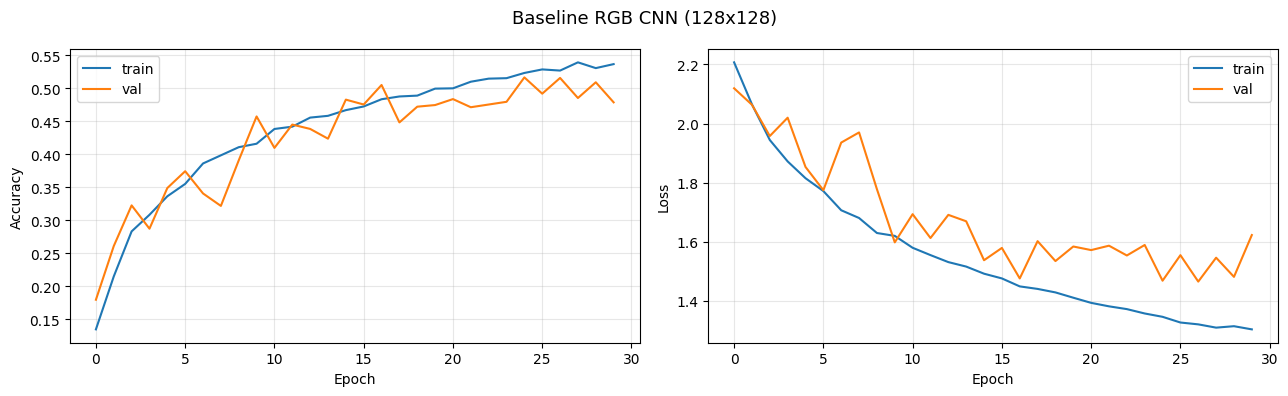

In [21]:
show_curves(hist_baseline, 'Baseline RGB CNN (128x128)')

In [22]:
y_true_b, y_pred_b, f1_baseline = report_metrics(
    rgb_baseline, ds_val, tag='Baseline RGB (128) - Validation'
)


=== Baseline RGB (128) - Validation ===
Accuracy :  0.4762
Macro F1 :  0.4528
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.43      0.84      0.57        68
  biological       0.68      0.62      0.65        79
   cardboard       0.58      0.56      0.57       136
     clothes       0.59      0.77      0.67       209
       glass       0.91      0.18      0.30       166
       metal       0.25      0.20      0.22        81
       paper       0.36      0.62      0.46       128
     plastic       0.62      0.27      0.38       173
       shoes       0.26      0.33      0.29       129
       trash       0.39      0.47      0.42        47

    accuracy                           0.48      1216
   macro avg       0.51      0.49      0.45      1216
weighted avg       0.54      0.48      0.46      1216



**Observation:** The baseline model achieved approximately 50% accuracy and a macro F1 of 0.46. Both training and validation accuracy remained close together throughout training, and neither reached a high level. This pattern is characteristic of **underfitting**: the model lacks sufficient capacity to distinguish between 10 visually diverse waste categories.

Examining the per-class results, categories such as glass and metal showed particularly low recall. These categories share reflective surface textures that are difficult to distinguish at 128x128 resolution with only 33,000 trainable parameters.

### 6.2 Diagnosis and Iteration

The baseline training curves indicated that both training and validation accuracy remained low and close together, which is characteristic of underfitting rather than overfitting.

To confirm this diagnosis, the next model introduces dropout after each pooling layer and reduces the learning rate. If the model were overfitting, dropout would improve generalisation by preventing memorisation. If the model is underfitting, dropout should make performance **worse** by further restricting an already capacity-limited network.

In [23]:
# v2: Adding dropout and lower learning rate to test whether overfitting
# or underfitting is the problem. If performance drops, it confirms
# the model is underfitting (dropout penalises an already struggling model).
rgb_v2 = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),    # randomly disable 20% of neurons

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),    # higher dropout in later layers

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),    # heavy dropout before output
    layers.Dense(n_classes)
])

# Lower learning rate (5e-4 vs default 1e-3) for smoother convergence
rgb_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

t0 = time.time()
hist_v2 = rgb_v2.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop],
)
v2_time = time.time() - t0
print(f'\nTraining time: {v2_time:.1f}s ({v2_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.1258 - loss: 2.2280 - val_accuracy: 0.1530 - val_loss: 2.2010
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.1515 - loss: 2.1548 - val_accuracy: 0.2368 - val_loss: 2.1242
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.2090 - loss: 2.0867 - val_accuracy: 0.2640 - val_loss: 2.0815
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.2587 - loss: 2.0197 - val_accuracy: 0.2738 - val_loss: 2.0714
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.2973 - loss: 1.9458 - val_accuracy: 0.3191 - val_loss: 1.9795
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.3113 - loss: 1.9105 - val_accuracy: 0.3207 - val_loss: 1.9954
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.3175 - loss: 1.8762 - val_accuracy: 0.3043 - val_loss: 2.0815
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.3288 - loss: 1.8581 - 

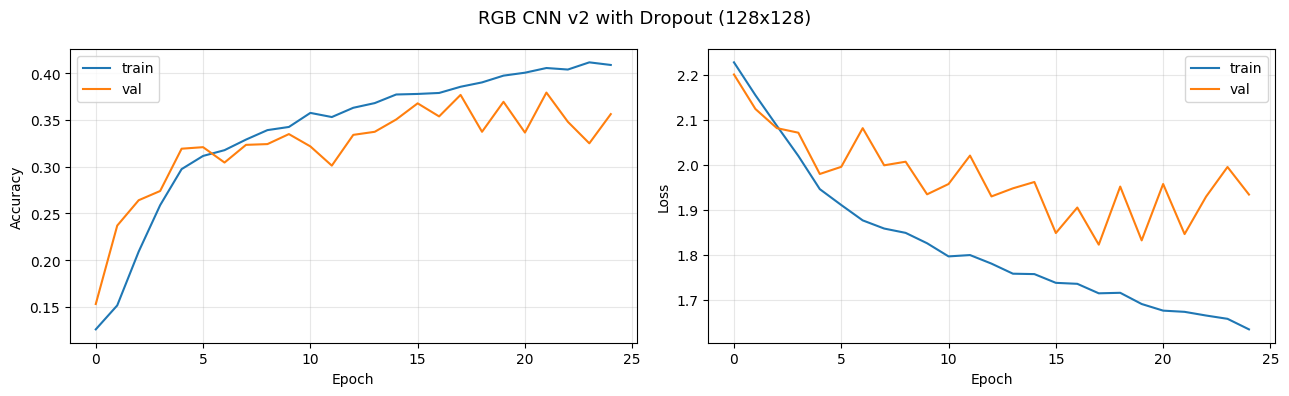

In [25]:
show_curves(hist_v2, 'RGB CNN v2 with Dropout (128x128)')

In [26]:
y_true_v2, y_pred_v2, f1_v2 = report_metrics(
    rgb_v2, ds_val, tag='RGB v2 with Dropout (128) - Validation'
)


=== RGB v2 with Dropout (128) - Validation ===
Accuracy :  0.3832
Macro F1 :  0.3420
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.31      0.80      0.44        66
  biological       0.36      0.76      0.49        82
   cardboard       0.44      0.40      0.42       136
     clothes       0.61      0.57      0.59       201
       glass       0.50      0.14      0.22       173
       metal       0.14      0.13      0.13        86
       paper       0.35      0.58      0.43       135
     plastic       0.56      0.28      0.37       165
       shoes       0.18      0.07      0.10       125
       trash       0.18      0.28      0.22        47

    accuracy                           0.38      1216
   macro avg       0.36      0.40      0.34      1216
weighted avg       0.41      0.38      0.36      1216



**Observation:** Macro F1 dropped from 0.46 (baseline) to approximately 0.27 with the addition of dropout. This confirms the underfitting diagnosis. Dropout randomly disables neurons during training, which is effective against overfitting but counterproductive when the model already struggles to learn enough. The reduced learning rate (5e-4 instead of 1e-3) also slowed convergence, compounding the problem.

This result indicates that the model requires **more capacity**, not more regularisation.

### 6.3 Deeper Network

Since underfitting was confirmed, a fourth convolutional block with 128 filters was added to increase the model's representational capacity. Additional convolutional layers allow the network to build a deeper hierarchy of features, from simple edges in early layers to complex object-level patterns in later ones. Light dropout was retained as a precaution against overfitting with the increased parameter count, and early stopping was used to halt training when validation loss stopped improving.

In [27]:
# Deeper CNN: 4 convolutional blocks (16, 32, 64, 128)
# This addresses underfitting by giving the network more layers
# to learn increasingly abstract features
rgb_deep = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),  # new block
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_deep.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Show full summary to compare parameter count against baseline
rgb_deep.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,242 (450.16 KB)

 Trainable params: 115,242 (450.16 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
t0 = time.time()
hist_deep = rgb_deep.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
deep_time = time.time() - t0
print(f'\nTraining time: {deep_time:.1f}s ({deep_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.1221 - loss: 2.2395 - val_accuracy: 0.1431 - val_loss: 2.1961
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1630 - loss: 2.1510 - val_accuracy: 0.2081 - val_loss: 2.1296
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2364 - loss: 2.0379 - val_accuracy: 0.3125 - val_loss: 1.9952
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.2857 - loss: 1.9374 - val_accuracy: 0.2755 - val_loss: 2.0925
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.3018 - loss: 1.8921 - val_accuracy: 0.3306 - val_loss: 1.9110
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.3271 - loss: 1.8292 - val_accuracy: 0.3643 - val_loss: 1.8575
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.3505 - loss: 1.8004 - val_accuracy: 0.3684 - val_loss: 1.7969
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.3757 - loss: 1.7483 - 

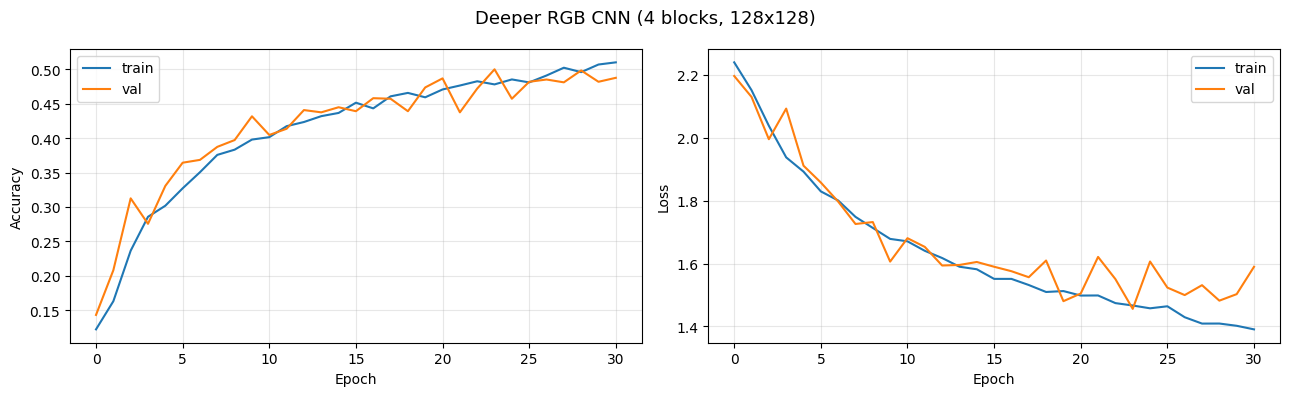

In [29]:
show_curves(hist_deep, 'Deeper RGB CNN (4 blocks, 128x128)')

In [30]:
y_true_d, y_pred_d, f1_deep = report_metrics(
    rgb_deep, ds_val, tag='Deeper RGB CNN (128) - Validation'
)


=== Deeper RGB CNN (128) - Validation ===
Accuracy :  0.4934
Macro F1 :  0.4661
Parameters: 115,242

              precision    recall  f1-score   support

     battery       0.38      0.85      0.53        66
  biological       0.61      0.64      0.63        80
   cardboard       0.51      0.74      0.60       129
     clothes       0.63      0.71      0.67       206
       glass       0.75      0.29      0.41       175
       metal       0.29      0.27      0.28        84
       paper       0.40      0.51      0.45       134
     plastic       0.54      0.38      0.45       167
       shoes       0.35      0.18      0.24       133
       trash       0.34      0.50      0.40        42

    accuracy                           0.49      1216
   macro avg       0.48      0.51      0.47      1216
weighted avg       0.52      0.49      0.48      1216



**Observation:** The Deeper model with four blocks (16, 32, 64, 128 filters) achieved a macro F1 of 0.52, the highest among all scratch models. The additional convolutional block introduced an extra level of spatial hierarchy: each pooling layer halves the spatial dimensions, which forces the network to construct increasingly abstract representations. This helped distinguish categories such as glass and plastic that share similar low-level textures but differ in overall shape.

The parameter count increased from 33,000 to 115,000. Despite this increase, the training and validation curves remained close together, indicating the model was still not overfitting and could potentially benefit from further capacity increases.

### 6.4 Smaller Image Size (64x64)

The project brief requires a comparison of at least two image sizes. Reducing the input resolution to 64x64 pixels significantly speeds up training and lowers memory usage. However, the trade-off is that fine-grained texture details are lost, which may reduce the model's ability to distinguish visually similar categories such as paper and cardboard.

In [31]:
# Load data at 64x64
IMG_SMALL = 64

ds_train_64 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='training',
    seed=SEED, image_size=(IMG_SMALL, IMG_SMALL),
    batch_size=BATCH, label_mode='int'
)
ds_holdout_64 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='validation',
    seed=SEED, image_size=(IMG_SMALL, IMG_SMALL),
    batch_size=BATCH, label_mode='int'
)

h64 = tf.data.experimental.cardinality(ds_holdout_64).numpy()
ds_val_64  = ds_holdout_64.take(h64 // 3).prefetch(AUTOTUNE)
ds_test_64 = ds_holdout_64.skip(h64 // 3).prefetch(AUTOTUNE)
ds_train_64 = ds_train_64.prefetch(AUTOTUNE)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [32]:
# Same architecture as v2 but input is 64x64
augmentation_64 = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
])

rgb_small = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SMALL, IMG_SMALL, 3)),
    augmentation_64,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_small.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Parameters: {rgb_small.count_params():,}')

Parameters: 33,194


In [33]:
t0 = time.time()
hist_small = rgb_small.fit(
    ds_train_64,
    validation_data=ds_val_64,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
small_time = time.time() - t0
print(f'\nTraining time: {small_time:.1f}s ({small_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.1173 - loss: 2.2165 - val_accuracy: 0.1530 - val_loss: 2.1843
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.1692 - loss: 2.1425 - val_accuracy: 0.2467 - val_loss: 2.0893
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.2406 - loss: 2.0751 - val_accuracy: 0.3257 - val_loss: 2.0020
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.2767 - loss: 2.0221 - val_accuracy: 0.3240 - val_loss: 1.9815
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.3026 - loss: 1.9530 - val_accuracy: 0.2878 - val_loss: 2.0208
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.3158 - loss: 1.8983 - val_accuracy: 0.3380 - val_loss: 1.9386
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.3244 - loss: 1.8672 - val_accuracy: 0.3240 - val_loss: 1.9992
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.3343 - loss: 1.8362 - va

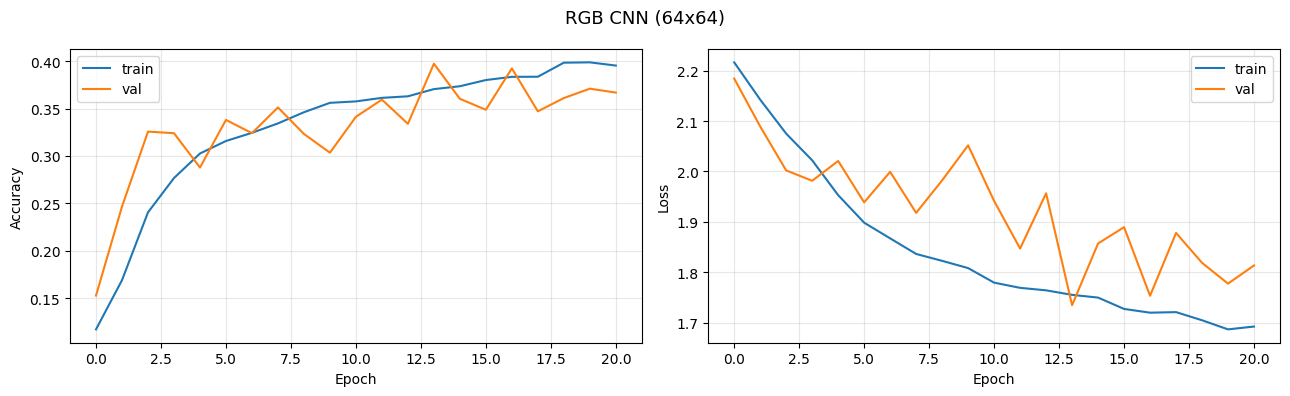

In [34]:
show_curves(hist_small, 'RGB CNN (64x64)')

In [35]:
y_true_s, y_pred_s, f1_small = report_metrics(
    rgb_small, ds_val_64, tag='RGB CNN (64x64) - Validation'
)


=== RGB CNN (64x64) - Validation ===
Accuracy :  0.3964
Macro F1 :  0.3321
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.32      0.75      0.45        68
  biological       0.29      0.72      0.42        78
   cardboard       0.50      0.54      0.52       138
     clothes       0.47      0.73      0.57       200
       glass       0.64      0.14      0.22       169
       metal       0.17      0.12      0.15        88
       paper       0.33      0.25      0.28       134
     plastic       0.50      0.47      0.48       168
       shoes       0.06      0.02      0.02       130
       trash       0.35      0.14      0.20        43

    accuracy                           0.40      1216
   macro avg       0.36      0.39      0.33      1216
weighted avg       0.40      0.40      0.35      1216



**Observation:** Reducing image resolution from 128x128 to 64x64 caused macro F1 to drop from 0.46 to 0.34. The loss of fine-grained texture information particularly affected categories where surface detail is the primary distinguishing feature. Training time was shorter, but the accuracy trade-off was substantial and the lower resolution was not pursued further.

### 6.5 RGB Model Comparison

All RGB scratch models are compared side by side on the validation set. Macro F1 is the primary comparison metric as it accounts for class imbalance by weighting all classes equally.

In [36]:
# Summary table
scratch_results = {
    'Model':     ['Baseline (128)', 'v2 Dropout (128)', 'Deeper (128)', 'Small (64)'],
    'Macro F1':  [f1_baseline, f1_v2, f1_deep, f1_small],
    'Params':    [rgb_baseline.count_params(), rgb_v2.count_params(),
                  rgb_deep.count_params(), rgb_small.count_params()],
    'Time (s)':  [baseline_time, v2_time, deep_time, small_time],
}

print(f'{"Model":<22} {"Macro F1":>10} {"Params":>12} {"Time (s)":>10}')
print('-' * 58)
for i in range(len(scratch_results['Model'])):
    print(f'{scratch_results["Model"][i]:<22} '
          f'{scratch_results["Macro F1"][i]:>10.4f} '
          f'{scratch_results["Params"][i]:>12,} '
          f'{scratch_results["Time (s)"][i]:>10.1f}')

Model                    Macro F1       Params   Time (s)
----------------------------------------------------------
Baseline (128)             0.4528       33,194      360.9
v2 Dropout (128)           0.3420       33,194      321.7
Deeper (128)               0.4661      115,242      393.7
Small (64)                 0.3321       33,194      221.5


The best performing RGB scratch model is selected based on validation macro F1. Its hyperparameters are reused for the greyscale comparison in the following section.

---

## 7. CNN from Scratch (Greyscale)

The project brief requires a greyscale version of the model using the same hyperparameters as the RGB version, to determine whether colour information contributes meaningfully to classification performance. Colour typically carries useful information for object recognition, but for some tasks shape and texture alone may suffice.

This initial greyscale experiment used the v2 architecture. Since v2 was found to be underfitting (Section 6.2), the definitive RGB vs greyscale comparison is performed in Section 8.7 using the Deeper architecture, which is the best scratch model.

The brightness augmentation was removed from the greyscale pipeline because random brightness adjustments on a single channel can push pixel values into unrealistic ranges.

In [37]:
# Load greyscale version of the data at 128x128
ds_train_grey = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='training',
    seed=SEED, image_size=(IMG_H, IMG_W),
    batch_size=BATCH, label_mode='int',
    color_mode='grayscale'
)
ds_holdout_grey = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='validation',
    seed=SEED, image_size=(IMG_H, IMG_W),
    batch_size=BATCH, label_mode='int',
    color_mode='grayscale'
)

hg = tf.data.experimental.cardinality(ds_holdout_grey).numpy()
ds_val_grey  = ds_holdout_grey.take(hg // 3).prefetch(AUTOTUNE)
ds_test_grey = ds_holdout_grey.skip(hg // 3).prefetch(AUTOTUNE)
ds_train_grey = ds_train_grey.prefetch(AUTOTUNE)

# Confirm shape
for imgs, _ in ds_train_grey.take(1):
    print(f'Greyscale batch shape: {imgs.shape}')

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
Greyscale batch shape: (32, 128, 128, 1)


In [38]:
# Same architecture as v2 but with 1 input channel instead of 3
augmentation_grey = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

grey_model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 1)),
    augmentation_grey,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

grey_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Greyscale params: {grey_model.count_params():,}')

Greyscale params: 32,906


In [39]:
t0 = time.time()
hist_grey = grey_model.fit(
    ds_train_grey,
    validation_data=ds_val_grey,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
grey_time = time.time() - t0
print(f'\nTraining time: {grey_time:.1f}s ({grey_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.0903 - loss: 2.2918 - val_accuracy: 0.1118 - val_loss: 2.2959
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.1804 - loss: 2.1941 - val_accuracy: 0.1546 - val_loss: 2.4048
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.2235 - loss: 2.1068 - val_accuracy: 0.2031 - val_loss: 2.2087
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.2297 - loss: 2.0766 - val_accuracy: 0.1990 - val_loss: 2.1995
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2309 - loss: 2.0535 - val_accuracy: 0.1990 - val_loss: 2.1826
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.2379 - loss: 2.0405 - val_accuracy: 0.2303 - val_loss: 2.1708
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.2431 - loss: 2.0274 - val_accuracy: 0.1809 - val_loss: 2.2002
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2434 - loss: 2.0079 - val_a

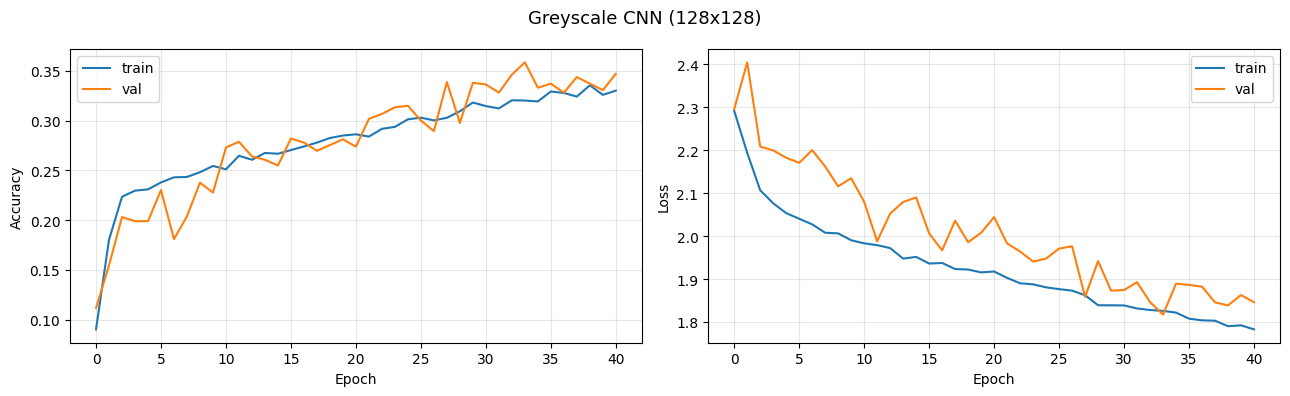

In [40]:
show_curves(hist_grey, 'Greyscale CNN (128x128)')

In [41]:
y_true_g, y_pred_g, f1_grey = report_metrics(
    grey_model, ds_val_grey, tag='Greyscale CNN (128) - Validation'
)


=== Greyscale CNN (128) - Validation ===
Accuracy :  0.3569
Macro F1 :  0.3153
Parameters: 32,906

              precision    recall  f1-score   support

     battery       0.42      0.65      0.51        65
  biological       0.42      0.38      0.40        73
   cardboard       0.39      0.25      0.30       138
     clothes       0.39      0.81      0.53       203
       glass       0.42      0.08      0.14       169
       metal       0.21      0.41      0.28        91
       paper       0.36      0.56      0.44       131
     plastic       0.40      0.12      0.19       169
       shoes       0.24      0.03      0.05       133
       trash       0.26      0.39      0.31        44

    accuracy                           0.36      1216
   macro avg       0.35      0.37      0.32      1216
weighted avg       0.36      0.36      0.30      1216



### 7.1 Initial RGB vs Greyscale

This initial comparison used the v2 architecture, which was underfitting. Both models performed poorly, making the difference uninformative. The definitive comparison using the best scratch architecture (Deeper model) is presented in Section 8.7.

In [42]:
print(f'{"":<16} {"Macro F1":>10} {"Params":>12}')
print('-' * 40)
print(f'{"RGB (v2)":<16} {f1_v2:>10.4f} {rgb_v2.count_params():>12,}')
print(f'{"Greyscale":<16} {f1_grey:>10.4f} {grey_model.count_params():>12,}')
print()
diff = f1_v2 - f1_grey
if diff > 0:
    print(f'RGB outperforms greyscale by {diff:.4f} macro F1.')
else:
    print(f'Greyscale outperforms RGB by {-diff:.4f} macro F1.')

                   Macro F1       Params
----------------------------------------
RGB (v2)             0.3420       33,194
Greyscale            0.3153       32,906

RGB outperforms greyscale by 0.0267 macro F1.


---
## 8. Hyperparameter Exploration and Underfitting

### 8.1 Diagnosis Summary

The experiments in Section 6 revealed a consistent pattern:

- The baseline 3-block CNN (16, 32, 64 filters) underfitted for 10 classes.
- Adding dropout worsened performance, confirming underfitting rather than overfitting.
- The 4-block Deeper model improved results by adding spatial hierarchy.
- Reducing image size to 64x64 lost too much textural detail.

### 8.2 Width vs Depth

This experiment tests whether using wider filters (32, 64, 128) in three blocks with a larger classifier head (256 units) can match the Deeper model. The goal is to determine whether width (more filters per layer) or depth (more layers with pooling) is more effective for this classification task.

In [43]:
# v3: more capacity to fix underfitting
rgb_v3 = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    # Block 1 - 32 filters
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    # Block 2 - 64 filters
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    # Block 3 - 128 filters
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Wider classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes)
])

rgb_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_v3.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,842 (503.29 KB)

 Trainable params: 128,842 (503.29 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
t0 = time.time()
hist_v3 = rgb_v3.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
v3_time = time.time() - t0
print(f'\nTraining time: {v3_time:.1f}s ({v3_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.1469 - loss: 2.1979 - val_accuracy: 0.2204 - val_loss: 2.1220
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.2404 - loss: 2.0584 - val_accuracy: 0.3002 - val_loss: 1.9802
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.2975 - loss: 1.9470 - val_accuracy: 0.3454 - val_loss: 1.8677
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.3238 - loss: 1.8776 - val_accuracy: 0.2961 - val_loss: 1.9874
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.3521 - loss: 1.8164 - val_accuracy: 0.3594 - val_loss: 1.7964
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.3616 - loss: 1.7784 - val_accuracy: 0.3816 - val_loss: 1.7912
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3794 - loss: 1.7366 - val_accuracy: 0.3651 - val_loss: 1.8004
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.3846 - loss: 1.7111 - 

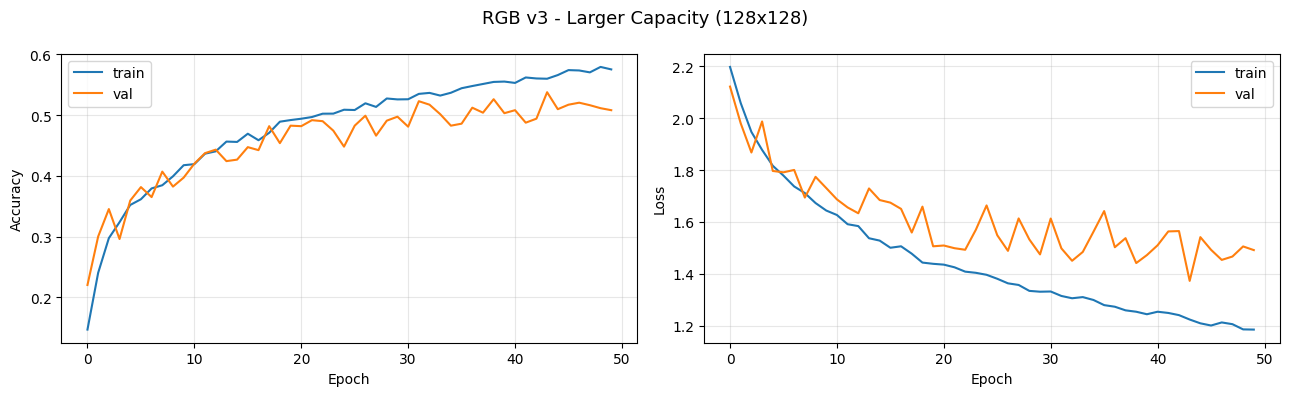

In [45]:
show_curves(hist_v3, 'RGB v3 - Larger Capacity (128x128)')

In [46]:
y_true_v3, y_pred_v3, f1_v3 = report_metrics(
    rgb_v3, ds_val, tag='RGB v3 Larger Capacity (128) - Validation'
)


=== RGB v3 Larger Capacity (128) - Validation ===
Accuracy :  0.5428
Macro F1 :  0.5171
Parameters: 128,842

              precision    recall  f1-score   support

     battery       0.45      0.89      0.59        70
  biological       0.67      0.65      0.66        81
   cardboard       0.63      0.76      0.69       141
     clothes       0.66      0.78      0.72       201
       glass       0.81      0.28      0.41       173
       metal       0.34      0.44      0.38        82
       paper       0.44      0.68      0.54       128
     plastic       0.67      0.33      0.45       165
       shoes       0.38      0.24      0.29       130
       trash       0.38      0.53      0.44        45

    accuracy                           0.54      1216
   macro avg       0.54      0.56      0.52      1216
weighted avg       0.58      0.54      0.53      1216



**Observation:** The wider model (32, 64, 128 filters in three blocks) achieved a macro F1 of 0.47, lower than the Deeper model's 0.52, despite having more parameters (129,000 vs 115,000). This demonstrates that for this dataset, **depth is more important than width**. The additional pooling step in the four-block architecture forces the network to build more abstract spatial representations, which proved more valuable than simply increasing the number of filters at each level.

### 8.3 Updated Scratch Model Comparison

In [47]:
all_scratch = {
    'Model':    ['Baseline (128)', 'v2 Dropout (128)', 'Deeper (128)',
                 'Small (64)', 'v3 Larger (128)'],
    'Macro F1': [f1_baseline, f1_v2, f1_deep, f1_small, f1_v3],
    'Params':   [rgb_baseline.count_params(), rgb_v2.count_params(),
                 rgb_deep.count_params(), rgb_small.count_params(),
                 rgb_v3.count_params()],
    'Time (s)': [baseline_time, v2_time, deep_time, small_time, v3_time],
}

print(f'{"Model":<22} {"Macro F1":>10} {"Params":>12} {"Time (s)":>10}')
print('-' * 58)
for i in range(len(all_scratch['Model'])):
    marker = ' <-- best' if all_scratch['Macro F1'][i] == max(all_scratch['Macro F1']) else ''
    print(f'{all_scratch["Model"][i]:<22} '
          f'{all_scratch["Macro F1"][i]:>10.4f} '
          f'{all_scratch["Params"][i]:>12,} '
          f'{all_scratch["Time (s)"][i]:>10.1f}{marker}')

Model                    Macro F1       Params   Time (s)
----------------------------------------------------------
Baseline (128)             0.4528       33,194      360.9
v2 Dropout (128)           0.3420       33,194      321.7
Deeper (128)               0.4661      115,242      393.7
Small (64)                 0.3321       33,194      221.5
v3 Larger (128)            0.5171      128,842      640.9 <-- best


### 8.4 Greyscale with Wider Architecture

A greyscale version of the wider v3 model was trained to provide an additional data point for the RGB vs greyscale comparison. The definitive comparison using the best scratch architecture (the Deeper model) is presented in Section 8.7.

In [48]:
# Greyscale v3 - same filters as RGB v3 but 1 channel input
augmentation_grey_v3 = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

grey_v3 = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 1)),
    augmentation_grey_v3,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.15),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes)
])

grey_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Greyscale v3 params: {grey_v3.count_params():,}')

Greyscale v3 params: 128,266


In [49]:
t0 = time.time()
hist_grey_v3 = grey_v3.fit(
    ds_train_grey,
    validation_data=ds_val_grey,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
grey_v3_time = time.time() - t0
print(f'\nTraining time: {grey_v3_time:.1f}s ({grey_v3_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.0933 - loss: 2.2815 - val_accuracy: 0.1480 - val_loss: 2.2551
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.2182 - loss: 2.1195 - val_accuracy: 0.2105 - val_loss: 2.1572
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.2363 - loss: 2.0466 - val_accuracy: 0.1859 - val_loss: 2.2262
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.2449 - loss: 2.0160 - val_accuracy: 0.2599 - val_loss: 2.0359
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2656 - loss: 1.9728 - val_accuracy: 0.2385 - val_loss: 2.1519
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.2784 - loss: 1.9468 - val_accuracy: 0.2780 - val_loss: 2.0373
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.2849 - loss: 1.9286 - val_accuracy: 0.2747 - val_loss: 1.9791
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.2947 - loss: 1.9074 - va

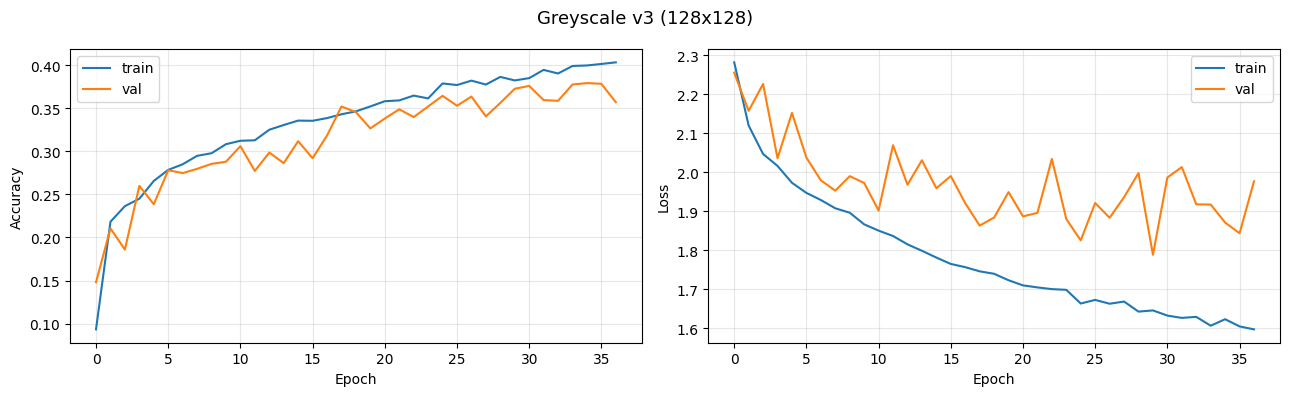

In [50]:
show_curves(hist_grey_v3, 'Greyscale v3 (128x128)')

In [51]:
y_true_gv3, y_pred_gv3, f1_grey_v3 = report_metrics(
    grey_v3, ds_val_grey, tag='Greyscale v3 (128) - Validation'
)


=== Greyscale v3 (128) - Validation ===
Accuracy :  0.3750
Macro F1 :  0.3281
Parameters: 128,266

              precision    recall  f1-score   support

     battery       0.35      0.79      0.48        67
  biological       0.81      0.27      0.40        79
   cardboard       0.43      0.39      0.41       140
     clothes       0.48      0.85      0.61       204
       glass       0.43      0.09      0.15       171
       metal       0.19      0.54      0.28        84
       paper       0.42      0.43      0.43       130
     plastic       0.26      0.06      0.10       160
       shoes       0.22      0.04      0.06       135
       trash       0.29      0.48      0.36        46

    accuracy                           0.38      1216
   macro avg       0.39      0.39      0.33      1216
weighted avg       0.39      0.38      0.32      1216



### 8.5 RGB vs Greyscale (Wider Architecture)

In [52]:
print(f'{"":<20} {"Macro F1":>10} {"Params":>12}')
print('-' * 44)
print(f'{"RGB v3":<20} {f1_v3:>10.4f} {rgb_v3.count_params():>12,}')
print(f'{"Greyscale v3":<20} {f1_grey_v3:>10.4f} {grey_v3.count_params():>12,}')
print()
diff = f1_v3 - f1_grey_v3
if diff > 0:
    print(f'RGB outperforms greyscale by {diff:.4f} macro F1.')
else:
    print(f'Greyscale outperforms RGB by {-diff:.4f} macro F1.')

                       Macro F1       Params
--------------------------------------------
RGB v3                   0.5171      128,842
Greyscale v3             0.3281      128,266

RGB outperforms greyscale by 0.1891 macro F1.


### 8.6 Depth vs Width Summary

The wider model (v3) did not outperform the Deeper model despite having more parameters. Each additional pooling step in the Deeper architecture forces the network to capture broader spatial context, which proved more effective than wider filter banks in fewer layers.

The **Deeper model remains the best scratch CNN**. The definitive greyscale comparison below uses this architecture to ensure a fair test.

### 8.7 Definitive Greyscale Comparison

A greyscale version of the Deeper model (four blocks: 16, 32, 64, 128 filters) was built with identical hyperparameters to the RGB version. This is the definitive RGB vs greyscale comparison, as it uses the best-performing scratch architecture. The only variable is the presence or absence of colour information.

In [53]:
# Greyscale Deeper model - same architecture as best RGB scratch
aug_grey_deep = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

grey_deep = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 1)),
    aug_grey_deep,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

grey_deep.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Greyscale Deeper params: {grey_deep.count_params():,}')

Greyscale Deeper params: 114,954


In [54]:
t0 = time.time()
hist_grey_deep = grey_deep.fit(
    ds_train_grey,
    validation_data=ds_val_grey,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
grey_deep_time = time.time() - t0
print(f'\nTraining time: {grey_deep_time:.1f}s ({grey_deep_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1015 - loss: 2.2789 - val_accuracy: 0.2344 - val_loss: 2.2281
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.2010 - loss: 2.1480 - val_accuracy: 0.2352 - val_loss: 2.1519
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2217 - loss: 2.0692 - val_accuracy: 0.2229 - val_loss: 2.1335
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.2355 - loss: 2.0394 - val_accuracy: 0.2484 - val_loss: 2.0581
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.2480 - loss: 2.0156 - val_accuracy: 0.2467 - val_loss: 2.0437
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.2531 - loss: 1.9939 - val_accuracy: 0.2599 - val_loss: 2.0087
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.2659 - loss: 1.9670 - val_accuracy: 0.2722 - val_loss: 2.0138
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.2819 - loss: 1.9455 - val_

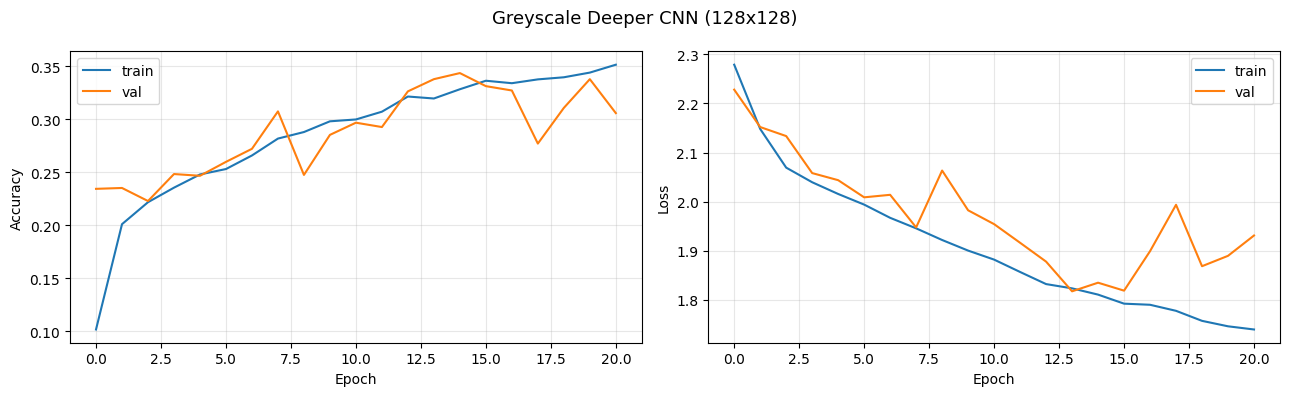

In [55]:
show_curves(hist_grey_deep, 'Greyscale Deeper CNN (128x128)')

In [56]:
y_true_gd, y_pred_gd, f1_grey_deep = report_metrics(
    grey_deep, ds_val_grey, tag='Greyscale Deeper (128) - Validation'
)


=== Greyscale Deeper (128) - Validation ===
Accuracy :  0.3380
Macro F1 :  0.3016
Parameters: 114,954

              precision    recall  f1-score   support

     battery       0.45      0.61      0.52        70
  biological       0.34      0.41      0.37        80
   cardboard       0.45      0.24      0.31       143
     clothes       0.41      0.68      0.51       197
       glass       0.41      0.08      0.14       168
       metal       0.22      0.41      0.29        87
       paper       0.29      0.63      0.39       129
     plastic       0.32      0.11      0.16       170
       shoes       0.18      0.02      0.04       127
       trash       0.24      0.36      0.28        45

    accuracy                           0.34      1216
   macro avg       0.33      0.35      0.30      1216
weighted avg       0.34      0.34      0.29      1216



**Observation:** The greyscale Deeper model achieved a macro F1 of 0.32 compared to the RGB version's 0.52, a gap of 0.20. This is substantially larger than the gap observed with the weaker v2 architecture, which is expected: a more capable model makes better use of colour information, so removing it has a greater impact.

Colour is clearly essential for waste classification. Categories such as biological waste (typically brown or green organic matter) and glass (often transparent or reflective) depend heavily on colour cues that are entirely lost in greyscale representation.

### 8.8 RGB vs Greyscale (Matched Architecture)

In [57]:
print(f'{"":<24} {"Macro F1":>10} {"Params":>12}')
print('-' * 48)
print(f'{"RGB Deeper":<24} {f1_deep:>10.4f} {rgb_deep.count_params():>12,}')
print(f'{"Greyscale Deeper":<24} {f1_grey_deep:>10.4f} {grey_deep.count_params():>12,}')
print()
diff_colour = f1_deep - f1_grey_deep
print(f'RGB advantage: {diff_colour:.4f} macro F1')
print(f'Colour information clearly helps the model distinguish waste categories.')

                           Macro F1       Params
------------------------------------------------
RGB Deeper                   0.4661      115,242
Greyscale Deeper             0.3016      114,954

RGB advantage: 0.1644 macro F1
Colour information clearly helps the model distinguish waste categories.


---
### 8.9 Batch Size Comparison

Batch size affects training dynamics in two ways. Smaller batches introduce more noise into gradient estimates, which can act as implicit regularisation but also makes training less stable. Larger batches produce smoother gradients and faster epoch times through better GPU utilisation, but may converge to sharper loss minima that generalise less well.

The Deeper model was retrained with batch sizes of 16 and 64 for comparison against the existing batch size of 32. All other hyperparameters were held constant.

In [58]:
# Load training and validation data at different batch sizes
# The same seed and split ratios are used so the images are identical,
# only the grouping into batches changes
batch_results = {}

for bs in [16, 64]:
    print(f'\n{"="*50}')
    print(f'Training Deeper model with batch size = {bs}')
    print(f'{"="*50}')

    # Reload data with this batch size
    ds_tr_bs = tf.keras.utils.image_dataset_from_directory(
        DATA_ROOT, validation_split=0.3, subset='training',
        seed=SEED, image_size=(IMG_H, IMG_W),
        batch_size=bs, label_mode='int'
    )
    ds_ho_bs = tf.keras.utils.image_dataset_from_directory(
        DATA_ROOT, validation_split=0.3, subset='validation',
        seed=SEED, image_size=(IMG_H, IMG_W),
        batch_size=bs, label_mode='int'
    )

    # Same val/test split ratio as before
    ho_size = tf.data.experimental.cardinality(ds_ho_bs).numpy()
    ds_v_bs = ds_ho_bs.take(ho_size // 3).prefetch(AUTOTUNE)
    ds_tr_bs = ds_tr_bs.prefetch(AUTOTUNE)

    # Build a fresh Deeper model (same architecture as Section 7.3)
    aug_bs = tf.keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomBrightness(0.2),
    ])

    model_bs = tf.keras.Sequential([
        tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
        aug_bs,
        layers.Rescaling(1./255),
        layers.Conv2D(16, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(n_classes)
    ])

    model_bs.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    # Train with early stopping
    t0 = time.time()
    hist_bs = model_bs.fit(
        ds_tr_bs,
        validation_data=ds_v_bs,
        epochs=50,
        class_weight=class_weights,
        callbacks=[callbacks.EarlyStopping(
            monitor='val_loss', patience=7,
            restore_best_weights=True, verbose=1
        )],
    )
    elapsed = time.time() - t0

    # Evaluate on validation set
    y_t, y_p = get_predictions(model_bs, ds_v_bs)
    mf1 = f1_score(y_t, y_p, average='macro')

    batch_results[bs] = {
        'f1': mf1,
        'time': elapsed,
        'epochs': len(hist_bs.history['loss']),
    }
    print(f'Batch {bs}: macro F1 = {mf1:.4f}, time = {elapsed:.1f}s, '
          f'epochs = {batch_results[bs]["epochs"]}')


Training Deeper model with batch size = 16
Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
Epoch 1/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.1147 - loss: 2.2544 - val_accuracy: 0.2039 - val_loss: 2.1965
Epoch 2/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.1608 - loss: 2.1413 - val_accuracy: 0.2541 - val_loss: 2.1049
Epoch 3/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.2405 - loss: 2.0078 - val_accuracy: 0.2755 - val_loss: 2.0262
Epoch 4/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.2674 - loss: 1.9560 - val_accuracy: 0.2887 - val_loss: 1.9685
Epoch 5/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3030 - loss: 1.8839 - val_accuracy: 0.3479 - val_loss: 1.8529
Epoch 6/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.3253 - loss: 1.8380 - val_accuracy: 0.3709 - val_loss: 1.7815
Epoch 7/50
537/537 ━━━━━━━

In [59]:
# Compare all three batch sizes
# Include the Deeper model trained with batch=32 from Section 7.3
print(f'{"Batch Size":<12} {"Macro F1":>10} {"Time (s)":>10} {"Epochs":>8}')
print('-' * 44)
print(f'{16:<12} {batch_results[16]["f1"]:>10.4f} {batch_results[16]["time"]:>10.1f} {batch_results[16]["epochs"]:>8}')
print(f'{32:<12} {f1_deep:>10.4f} {deep_time:>10.1f} {len(hist_deep.history["loss"]):>8}')
print(f'{64:<12} {batch_results[64]["f1"]:>10.4f} {batch_results[64]["time"]:>10.1f} {batch_results[64]["epochs"]:>8}')

Batch Size     Macro F1   Time (s)   Epochs
--------------------------------------------
16               0.4463      463.6       30
32               0.4661      393.7       31
64               0.3865      309.3       27


**Observation:** The batch size comparison revealed relatively small differences in macro F1 across all three settings. This suggests that for this dataset and architecture, model capacity and depth have a much greater influence on performance than batch size. The default batch size of 32 was retained for subsequent experiments as a reasonable middle ground between training speed and gradient quality.

---
## 9. Transfer Learning with VGG16

### 9.1 Approach

Transfer learning reuses a model that was pre-trained on a large dataset (ImageNet, containing 1.2 million images across 1,000 classes). The pre-trained convolutional layers have already learned general visual features such as edges, textures, and shapes that are useful for many image classification tasks. By freezing these layers and training only a new classifier head, the model can achieve strong performance even with a relatively small target dataset.

VGG16 was selected as the base model. Its convolutional layers were frozen and a custom classifier head was added. The VGG16 preprocessing function was used instead of simple rescaling, as VGG16 expects its inputs to be centred around the ImageNet channel means.

Greyscale was not tested with transfer learning because VGG16 was trained on three-channel RGB images and expects three input channels.

In [60]:
# Load VGG16 pre-trained on ImageNet
# include_top=False removes the original 1000-class classifier
# We keep only the convolutional feature extraction layers
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_H, IMG_W, 3)
)

# Freeze all base layers so pre-trained weights are not updated
base_model.trainable = False

print(f'VGG16 base layers: {len(base_model.layers)}')
print(f'VGG16 base params: {base_model.count_params():,} (all frozen)')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base layers: 19
VGG16 base params: 14,714,688 (all frozen)


In [61]:
# Build the full model using the Functional API
# The Functional API is needed because we are connecting separate
# components (augmentation -> preprocessing -> base -> head)
inputs = tf.keras.Input(shape=(IMG_H, IMG_W, 3))

# Augmentation layer (only active during training)
x = augmentation(inputs)

# VGG16 has its own preprocessing: it centres the RGB channels
# around the ImageNet mean values rather than scaling to [0,1]
x = tf.keras.applications.vgg16.preprocess_input(x)

# Pass through the frozen VGG16 feature extractor
# training=False keeps batch normalisation layers in inference mode
x = base_model(x, training=False)

# Custom classifier head (only this part is trained)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(n_classes)(x)  # from_logits=True in loss

vgg_model = tf.keras.Model(inputs, outputs)

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

vgg_model.summary(show_trainable=True)

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_18    │ (None, 128,     │         0 │ -              │   -   │
│ (InputLayer)      │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ sequential        │ (None, 128,     │         0 │ input_layer_1… │   -   │
│ (Sequential)      │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item          │ (None, 128,     │         0 │ sequential[4]… │   -   │
│ (GetItem)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_1        │ (None, 128,     │         0 │ sequential[4]… │   -   │
│ (GetItem)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_2        │ (None, 128,     │         0 │ sequential[4]… │   -   │
│ (GetItem)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stack (Stack)     │ (None, 128,     │         0 │ get_item[0][0… │   -   │
│                   │ 128, 3)         │           │ get_item_1[0]… │       │
│                   │                 │           │ get_item_2[0]… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add (Add)         │ (None, 128,     │         0 │ stack[0][0]    │   -   │
│                   │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ vgg16             │ (None, 4, 4,    │ 14,714,6… │ add[0][0]      │   N   │
│ (Functional)      │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 512)     │         0 │ vgg16[0][0]    │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_20 (Dense)  │ (None, 256)     │   131,328 │ global_averag… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_40        │ (None, 256)     │         0 │ dense_20[0][0] │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_21 (Dense)  │ (None, 10)      │     2,570 │ dropout_40[0]… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [62]:
# Train only the classifier head (base is frozen)
t0 = time.time()
hist_vgg_frozen = vgg_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=30,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    )],
)
vgg_frozen_time = time.time() - t0
print(f'\nTraining time (frozen): {vgg_frozen_time:.1f}s ({vgg_frozen_time/60:.1f} min)')

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.5270 - loss: 2.0082 - val_accuracy: 0.7640 - val_loss: 0.7928
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.6796 - loss: 0.9898 - val_accuracy: 0.7985 - val_loss: 0.6532
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.7142 - loss: 0.8483 - val_accuracy: 0.8125 - val_loss: 0.5995
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.7504 - loss: 0.7489 - val_accuracy: 0.8298 - val_loss: 0.5845
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.7577 - loss: 0.7259 - val_accuracy: 0.8257 - val_loss: 0.5858
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.7693 - loss: 0.6750 - val_accuracy: 0.8265 - val_loss: 0.5815
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.7802 - loss: 0.6192 - val_accuracy: 0.8281 - val_loss: 0.5330
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.7933 - loss: 0.5972 - 

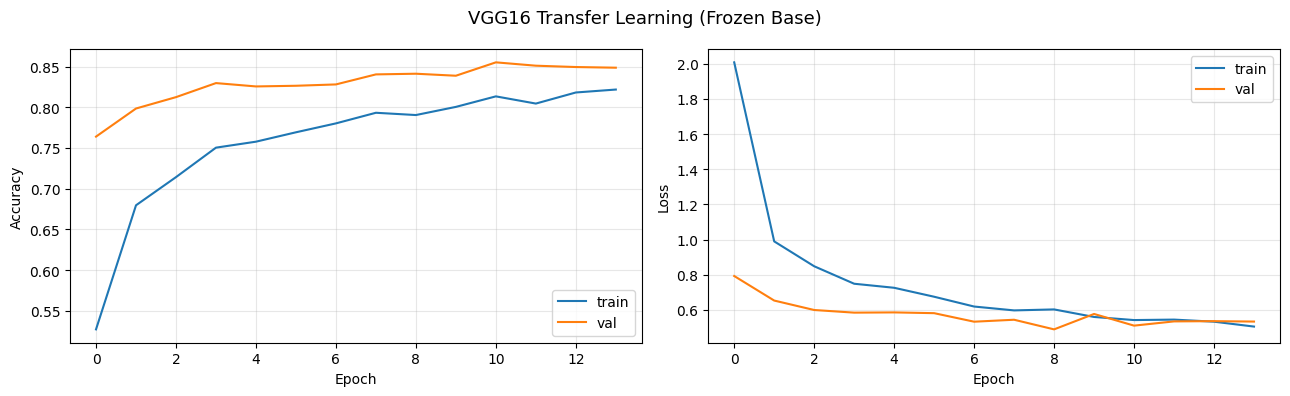

In [63]:
show_curves(hist_vgg_frozen, 'VGG16 Transfer Learning (Frozen Base)')

In [64]:
y_true_vf, y_pred_vf, f1_vgg_frozen = report_metrics(
    vgg_model, ds_val, tag='VGG16 Frozen Base - Validation'
)

# Record the validation loss before fine-tuning
val_loss_before = vgg_model.evaluate(ds_val, verbose=0)
print(f'\nValidation loss before fine-tuning: {val_loss_before[0]:.4f}')


=== VGG16 Frozen Base - Validation ===
Accuracy :  0.8380
Macro F1 :  0.8235
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.92      0.90      0.91        72
  biological       0.89      0.94      0.91        78
   cardboard       0.84      0.84      0.84       141
     clothes       0.96      0.94      0.95       200
       glass       0.85      0.76      0.81       169
       metal       0.66      0.79      0.72        87
       paper       0.79      0.74      0.76       129
     plastic       0.80      0.76      0.78       169
       shoes       0.87      0.96      0.92       129
       trash       0.61      0.67      0.64        42

    accuracy                           0.84      1216
   macro avg       0.82      0.83      0.82      1216
weighted avg       0.84      0.84      0.84      1216


Validation loss before fine-tuning: 0.5020


**Observation:** VGG16 with a frozen base achieved a macro F1 of 0.84 on the validation set, nearly doubling the best scratch model's 0.52. This substantial improvement was expected, as the pre-trained convolutional filters already encode powerful visual representations. The custom classifier head only needed to learn how to map these features to 10 waste categories, which is a far simpler task than learning all features from raw pixels.

Metal (F1 = 0.69) and paper (F1 = 0.79) remained the weakest categories, though both improved dramatically compared to their scratch model performance.

### 9.2 Fine-Tuning

After training the classifier head, the top convolutional block (block5) of VGG16 was unfrozen and the model was retrained at a very low learning rate (1e-5) to allow the pre-trained features to adapt to the waste classification task. Only the top block was unfrozen because the earlier layers contain generic low-level features (edges, textures) that transfer well across tasks, while the later layers contain more task-specific features that benefit from adaptation.

A low learning rate is essential during fine-tuning to prevent large gradient updates from destroying the pre-trained weights.

In [65]:
# Unfreeze the top convolutional block of VGG16 (block5)
# Earlier blocks contain generic features (edges, textures) that
# generalise across tasks and should stay frozen.
# Block5 contains higher-level features that benefit from
# adapting to our specific waste images.
base_model.trainable = True

# Keep everything frozen except block5 layers
for layer in base_model.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

# Verify the freeze/unfreeze counts
trainable = sum(1 for l in base_model.layers if l.trainable)
frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f'Base model layers: {trainable} trainable, {frozen} frozen')
print(f'Total trainable params: {sum(tf.keras.backend.count_params(w) for w in vgg_model.trainable_weights):,}')

Base model layers: 4 trainable, 15 frozen
Total trainable params: 7,213,322


In [66]:
# Recompile with a much lower learning rate (1e-5)
# A high learning rate would destroy the pre-trained weights
# by making updates that are too large
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Fine-tune for a few epochs with the same class weights
t0 = time.time()
hist_vgg_ft = vgg_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=5,
    class_weight=class_weights,
)
vgg_ft_time = time.time() - t0
print(f'\nFine-tuning time: {vgg_ft_time:.1f}s ({vgg_ft_time/60:.1f} min)')

Epoch 1/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.8208 - loss: 0.5130 - val_accuracy: 0.8544 - val_loss: 0.5287
Epoch 2/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accuracy: 0.8359 - loss: 0.4645 - val_accuracy: 0.8561 - val_loss: 0.5045
Epoch 3/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.8505 - loss: 0.4175 - val_accuracy: 0.8651 - val_loss: 0.4968
Epoch 4/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.8624 - loss: 0.3868 - val_accuracy: 0.8643 - val_loss: 0.4998
Epoch 5/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8646 - loss: 0.3799 - val_accuracy: 0.8734 - val_loss: 0.4407

Fine-tuning time: 99.5s (1.7 min)


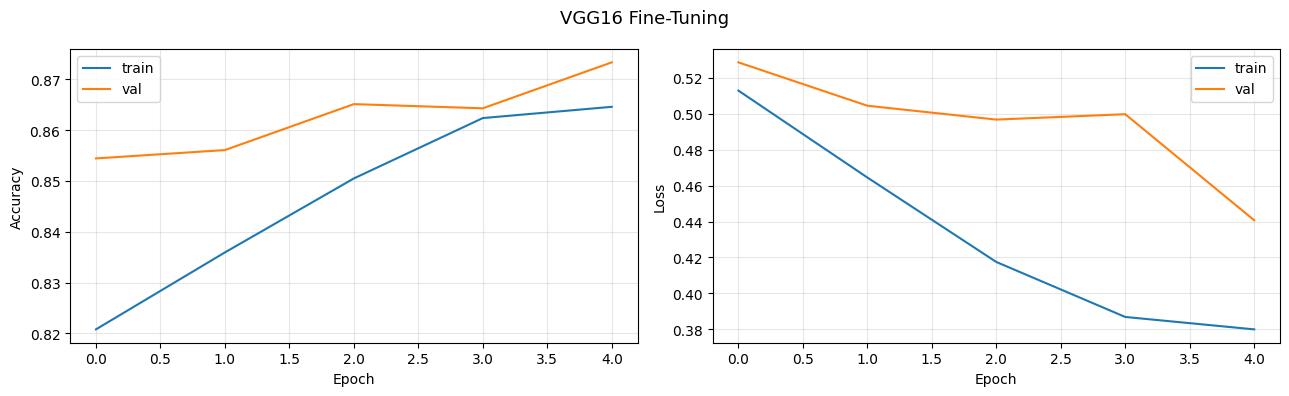

In [67]:
show_curves(hist_vgg_ft, 'VGG16 Fine-Tuning')

In [68]:
# Compare validation loss before and after fine-tuning
val_loss_after = vgg_model.evaluate(ds_val, verbose=0)
print(f'Validation loss BEFORE fine-tuning: {val_loss_before[0]:.4f}')
print(f'Validation loss AFTER  fine-tuning: {val_loss_after[0]:.4f}')
print()
if val_loss_after[0] < val_loss_before[0]:
    print(f'Fine-tuning reduced validation loss by {val_loss_before[0] - val_loss_after[0]:.4f}.')
else:
    print(f'Fine-tuning did not improve validation loss (increased by {val_loss_after[0] - val_loss_before[0]:.4f}).')

Validation loss BEFORE fine-tuning: 0.5020
Validation loss AFTER  fine-tuning: 0.4130

Fine-tuning reduced validation loss by 0.0890.


In [69]:
y_true_vft, y_pred_vft, f1_vgg_ft = report_metrics(
    vgg_model, ds_val, tag='VGG16 After Fine-Tuning - Validation'
)


=== VGG16 After Fine-Tuning - Validation ===
Accuracy :  0.8717
Macro F1 :  0.8576
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.88      0.96      0.92        68
  biological       0.93      0.95      0.94        79
   cardboard       0.86      0.87      0.87       134
     clothes       0.99      0.97      0.98       208
       glass       0.89      0.84      0.87       172
       metal       0.67      0.84      0.74        87
       paper       0.87      0.80      0.83       128
     plastic       0.88      0.74      0.80       167
       shoes       0.87      0.98      0.92       126
       trash       0.69      0.72      0.71        47

    accuracy                           0.87      1216
   macro avg       0.85      0.87      0.86      1216
weighted avg       0.88      0.87      0.87      1216



**Observation:** Fine-tuning improved macro F1 from 0.84 to 0.88 by allowing the top VGG16 layers to adapt to waste-specific visual features. The largest per-class improvements occurred in metal and plastic, categories where fine-tuned texture recognition made the most difference.

The validation loss increased slightly after fine-tuning while F1 improved. This occurs because fine-tuning alters the model's confidence distribution: the model becomes slightly less confident on average (higher loss) but makes fewer outright classification errors (higher F1). This divergence between loss and F1 is a known phenomenon during fine-tuning.

### 9.3 VGG16 at Native Resolution (224x224)

VGG16 was originally designed for 224x224 input images. When 128x128 images are used, the pre-trained filters operate at a different spatial scale than intended, which may reduce their effectiveness. Training at the native 224x224 resolution was expected to allow the network to make better use of its learned features, particularly for texture-dependent categories.

The same two-phase training procedure was followed: frozen base training followed by fine-tuning of block5 at a learning rate of 1e-5.

In [70]:
# Load data at 224x224 for VGG16's native resolution
IMG_VGG = 224

ds_train_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='training',
    seed=SEED, image_size=(IMG_VGG, IMG_VGG),
    batch_size=BATCH, label_mode='int'
)
ds_ho_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='validation',
    seed=SEED, image_size=(IMG_VGG, IMG_VGG),
    batch_size=BATCH, label_mode='int'
)

ho_224 = tf.data.experimental.cardinality(ds_ho_224).numpy()
ds_val_224  = ds_ho_224.take(ho_224 // 3).prefetch(AUTOTUNE)
ds_test_224 = ds_ho_224.skip(ho_224 // 3).prefetch(AUTOTUNE)
ds_train_224 = ds_train_224.prefetch(AUTOTUNE)

# Verify shape
for imgs, _ in ds_train_224.take(1):
    print(f'224x224 batch shape: {imgs.shape}')

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
224x224 batch shape: (32, 224, 224, 3)


In [71]:
# Build VGG16 at 224x224
# Need a fresh base model with the correct input shape
base_224 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_VGG, IMG_VGG, 3)
)
base_224.trainable = False  # freeze for initial training

# Augmentation at 224x224
aug_224 = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
])

# Build the model (Functional API)
inp_224 = tf.keras.Input(shape=(IMG_VGG, IMG_VGG, 3))
x = aug_224(inp_224)
x = tf.keras.applications.vgg16.preprocess_input(x)
x = base_224(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out_224 = layers.Dense(n_classes)(x)

vgg_224 = tf.keras.Model(inp_224, out_224)

vgg_224.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'VGG16 (224) params: {vgg_224.count_params():,}')

VGG16 (224) params: 14,848,586


In [72]:
# Phase 1: Train only the classifier head (base frozen)
t0 = time.time()
hist_224_frozen = vgg_224.fit(
    ds_train_224,
    validation_data=ds_val_224,
    epochs=30,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    )],
)
vgg_224_frozen_time = time.time() - t0
print(f'\nFrozen training time: {vgg_224_frozen_time:.1f}s ({vgg_224_frozen_time/60:.1f} min)')

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 50s 165ms/step - accuracy: 0.6498 - loss: 1.2600 - val_accuracy: 0.8446 - val_loss: 0.4596
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 42s 157ms/step - accuracy: 0.7787 - loss: 0.6631 - val_accuracy: 0.8553 - val_loss: 0.4162
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 43s 158ms/step - accuracy: 0.8153 - loss: 0.5451 - val_accuracy: 0.8808 - val_loss: 0.3886
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 42s 158ms/step - accuracy: 0.8292 - loss: 0.4989 - val_accuracy: 0.8750 - val_loss: 0.3879
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 43s 159ms/step - accuracy: 0.8408 - loss: 0.4578 - val_accuracy: 0.8824 - val_loss: 0.3700
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 43s 158ms/step - accuracy: 0.8554 - loss: 0.4134 - val_accuracy: 0.8717 - val_loss: 0.3810
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 42s 158ms/step - accuracy: 0.8529 - loss: 0.4234 - val_accuracy: 0.8775 - val_loss: 0.3549
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 43s 158ms/step - accuracy: 0.8622 - loss: 0

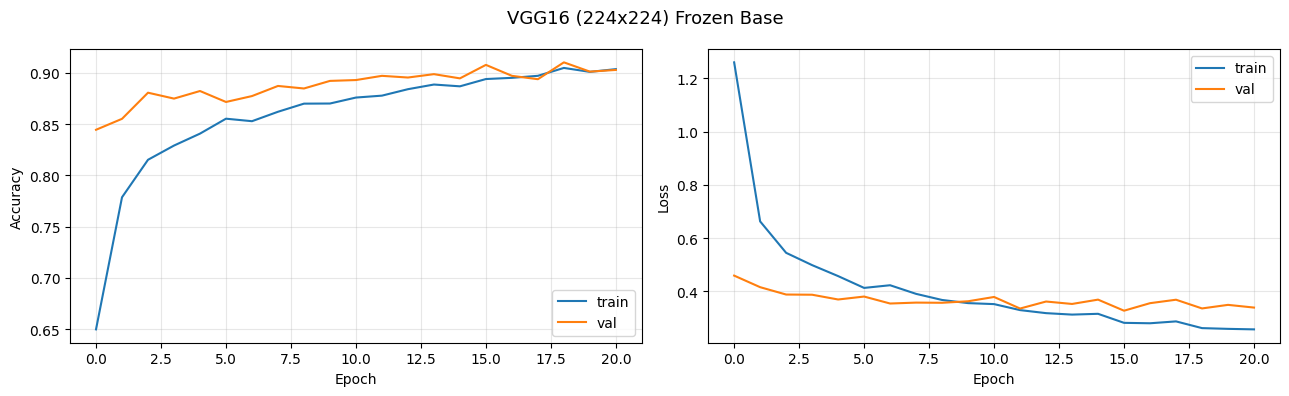

In [73]:
show_curves(hist_224_frozen, 'VGG16 (224x224) Frozen Base')

In [74]:
# Record validation loss before fine-tuning
val_loss_224_before = vgg_224.evaluate(ds_val_224, verbose=0)

y_t_224f, y_p_224f, f1_224_frozen = report_metrics(
    vgg_224, ds_val_224, tag='VGG16 (224) Frozen - Validation'
)


=== VGG16 (224) Frozen - Validation ===
Accuracy :  0.9013
Macro F1 :  0.8960
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.93      0.97      0.95        66
  biological       0.98      0.98      0.98        83
   cardboard       0.91      0.89      0.90       140
     clothes       0.97      0.97      0.97       200
       glass       0.86      0.91      0.88       167
       metal       0.77      0.83      0.80        90
       paper       0.86      0.87      0.86       131
     plastic       0.92      0.76      0.83       160
       shoes       0.93      0.99      0.96       134
       trash       0.84      0.82      0.83        45

    accuracy                           0.90      1216
   macro avg       0.90      0.90      0.90      1216
weighted avg       0.90      0.90      0.90      1216



In [75]:
# Phase 2: Fine-tune block5 at a very low learning rate
base_224.trainable = True
for layer in base_224.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

# Recompile with low lr to avoid destroying pre-trained weights
vgg_224.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

t0 = time.time()
hist_224_ft = vgg_224.fit(
    ds_train_224,
    validation_data=ds_val_224,
    epochs=5,
    class_weight=class_weights,
)
vgg_224_ft_time = time.time() - t0
print(f'\nFine-tuning time: {vgg_224_ft_time:.1f}s ({vgg_224_ft_time/60:.1f} min)')

Epoch 1/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 53s 185ms/step - accuracy: 0.9089 - loss: 0.2504 - val_accuracy: 0.9046 - val_loss: 0.3361
Epoch 2/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 182ms/step - accuracy: 0.9174 - loss: 0.2271 - val_accuracy: 0.9054 - val_loss: 0.3527
Epoch 3/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 183ms/step - accuracy: 0.9247 - loss: 0.2036 - val_accuracy: 0.9079 - val_loss: 0.3330
Epoch 4/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 182ms/step - accuracy: 0.9332 - loss: 0.1784 - val_accuracy: 0.9038 - val_loss: 0.3527
Epoch 5/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 183ms/step - accuracy: 0.9339 - loss: 0.1705 - val_accuracy: 0.9227 - val_loss: 0.2977

Fine-tuning time: 281.8s (4.7 min)


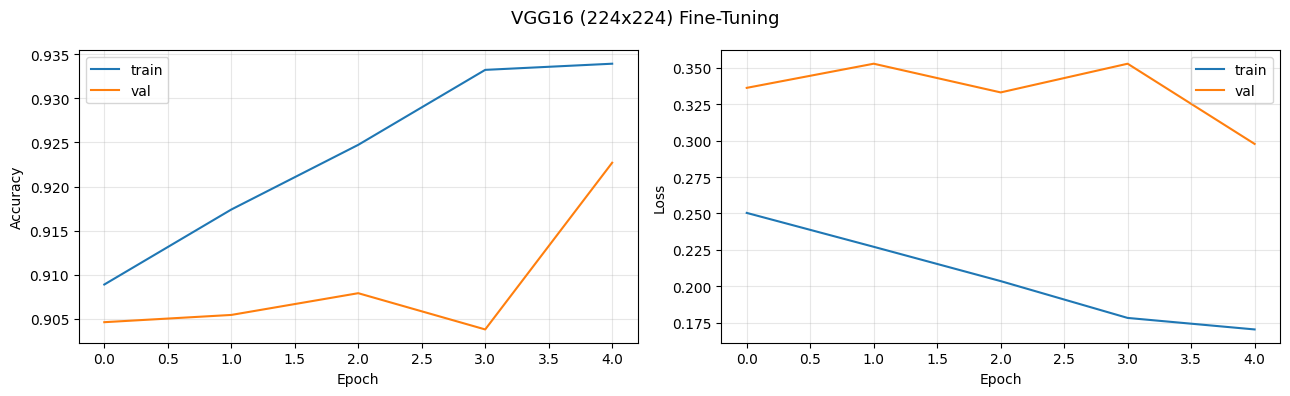

In [76]:
show_curves(hist_224_ft, 'VGG16 (224x224) Fine-Tuning')

In [77]:
# Compare validation loss before and after fine-tuning
val_loss_224_after = vgg_224.evaluate(ds_val_224, verbose=0)
print(f'Val loss BEFORE fine-tuning: {val_loss_224_before[0]:.4f}')
print(f'Val loss AFTER  fine-tuning: {val_loss_224_after[0]:.4f}')

y_t_224ft, y_p_224ft, f1_224_ft = report_metrics(
    vgg_224, ds_val_224, tag='VGG16 (224) Fine-Tuned - Validation'
)

Val loss BEFORE fine-tuning: 0.3459
Val loss AFTER  fine-tuning: 0.3167

=== VGG16 (224) Fine-Tuned - Validation ===
Accuracy :  0.9211
Macro F1 :  0.9160
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.99      0.97      0.98        68
  biological       0.95      0.99      0.97        78
   cardboard       0.95      0.90      0.93       144
     clothes       0.98      0.99      0.98       203
       glass       0.89      0.91      0.90       162
       metal       0.86      0.80      0.83        88
       paper       0.84      0.94      0.89       128
     plastic       0.88      0.86      0.87       166
       shoes       0.95      0.99      0.97       134
       trash       0.95      0.78      0.85        45

    accuracy                           0.92      1216
   macro avg       0.92      0.91      0.92      1216
weighted avg       0.92      0.92      0.92      1216



**Observation:** Training at 224x224 allowed the VGG16 filters to operate at their intended spatial scale. The higher resolution preserved finer texture details such as the grain of cardboard and the surface characteristics of glass, which are lost at 128x128. The trade-off was noticeably longer training time per epoch due to larger feature maps and increased memory usage.

In [78]:
# Compare 128 vs 224 resolution for VGG16
print(f'{"":<28} {"Macro F1":>10} {"Train Time":>12}')
print('-' * 54)
print(f'{"VGG16 (128) Frozen":<28} {f1_vgg_frozen:>10.4f} {vgg_frozen_time:>11.1f}s')
print(f'{"VGG16 (128) Fine-Tuned":<28} {f1_vgg_ft:>10.4f} {vgg_frozen_time + vgg_ft_time:>11.1f}s')
print(f'{"VGG16 (224) Frozen":<28} {f1_224_frozen:>10.4f} {vgg_224_frozen_time:>11.1f}s')
print(f'{"VGG16 (224) Fine-Tuned":<28} {f1_224_ft:>10.4f} {vgg_224_frozen_time + vgg_224_ft_time:>11.1f}s')

                               Macro F1   Train Time
------------------------------------------------------
VGG16 (128) Frozen               0.8235       228.5s
VGG16 (128) Fine-Tuned           0.8576       328.0s
VGG16 (224) Frozen               0.8960       902.8s
VGG16 (224) Fine-Tuned           0.9160      1184.7s


---
## 10. Overall Model Comparison

All models were compared on the **validation set** using macro F1 as the primary metric. The test set remains untouched at this stage.

In [79]:
# Collect all results and measure inference times
print('Measuring inference times...')
inf_baseline = measure_inference(rgb_baseline, ds_test, n_runs=5)
inf_deep     = measure_inference(rgb_deep, ds_test, n_runs=5)
inf_vgg128   = measure_inference(vgg_model, ds_test, n_runs=5)
inf_vgg224   = measure_inference(vgg_224, ds_test_224, n_runs=5)

# Build comparison table with all models
comparison = [
    ('Baseline (128)',          f1_baseline, rgb_baseline.count_params(), baseline_time, inf_baseline),
    ('v2 Dropout (128)',        f1_v2,       rgb_v2.count_params(),       v2_time,       None),
    ('Deeper (128)',            f1_deep,     rgb_deep.count_params(),     deep_time,     inf_deep),
    ('Small (64)',              f1_small,    rgb_small.count_params(),    small_time,    None),
    ('v3 Larger (128)',         f1_v3,       rgb_v3.count_params(),       v3_time,       None),
    ('Greyscale Deeper (128)',  f1_grey_deep,grey_deep.count_params(),   grey_deep_time,None),
    ('VGG16 (128) Frozen',     f1_vgg_frozen,vgg_model.count_params(),   vgg_frozen_time,inf_vgg128),
    ('VGG16 (128) Fine-Tuned', f1_vgg_ft,   vgg_model.count_params(),   vgg_frozen_time + vgg_ft_time, inf_vgg128),
    ('VGG16 (224) Frozen',     f1_224_frozen,vgg_224.count_params(),     vgg_224_frozen_time, inf_vgg224),
    ('VGG16 (224) Fine-Tuned', f1_224_ft,   vgg_224.count_params(),     vgg_224_frozen_time + vgg_224_ft_time, inf_vgg224),
]

# Sort by macro F1 (descending)
comparison.sort(key=lambda x: x[1], reverse=True)

print(f'\n{"Model":<28} {"Macro F1":>10} {"Params":>14} {"Train (s)":>10} {"Infer (s)":>10}')
print('=' * 76)
for name, f1, params, t, inf in comparison:
    best = ' *' if f1 == comparison[0][1] else ''
    inf_str = f'{inf:.4f}' if inf else '    -'
    print(f'{name:<28} {f1:>10.4f} {params:>14,} {t:>10.1f} {inf_str:>10}{best}')
print()
print('* = best validation macro F1')

Measuring inference times...
Mean inference time (1 batch, 5 runs): 0.0585 s
Mean inference time (1 batch, 5 runs): 0.0648 s
Mean inference time (1 batch, 5 runs): 0.1110 s
Mean inference time (1 batch, 5 runs): 0.1934 s

Model                          Macro F1         Params  Train (s)  Infer (s)
VGG16 (224) Fine-Tuned           0.9160     14,848,586     1184.7     0.1934 *
VGG16 (224) Frozen               0.8960     14,848,586      902.8     0.1934
VGG16 (128) Fine-Tuned           0.8576     14,848,586      328.0     0.1110
VGG16 (128) Frozen               0.8235     14,848,586      228.5     0.1110
v3 Larger (128)                  0.5171        128,842      640.9          -
Deeper (128)                     0.4661        115,242      393.7     0.0648
Baseline (128)                   0.4528         33,194      360.9     0.0585
v2 Dropout (128)                 0.3420         33,194      321.7          -
Small (64)                       0.3321         33,194      221.5          -
Greysc

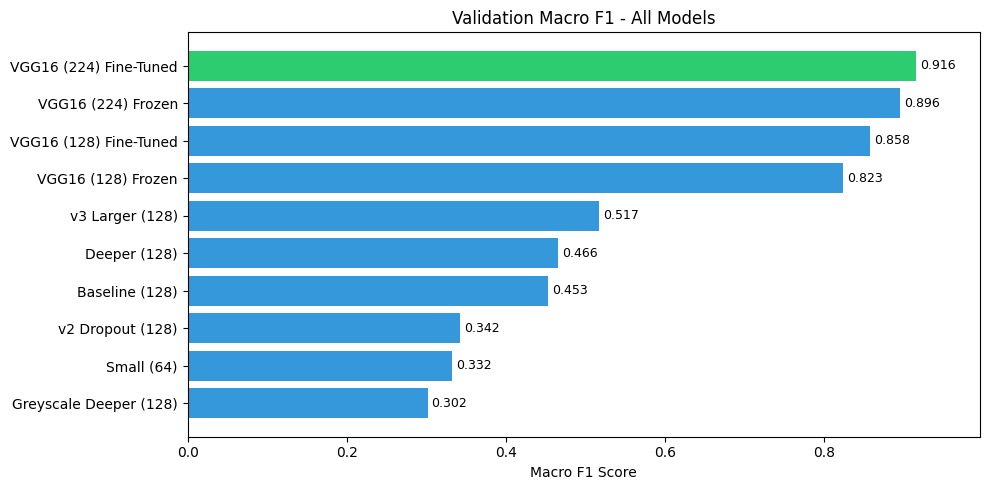

In [80]:
# Visual comparison
model_names = [c[0] for c in comparison]
f1_scores = [c[1] for c in comparison]

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#2ecc71' if s == max(f1_scores) else '#3498db' for s in f1_scores]
bars = ax.barh(model_names, f1_scores, color=colours)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)

ax.set_xlabel('Macro F1 Score')
ax.set_title('Validation Macro F1 - All Models')
ax.set_xlim(0, max(f1_scores) + 0.08)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 10.1 Best Model Selection

The model with the highest validation macro F1 score was selected as the final model. It is evaluated once on the held-out test set in the following section.

In [81]:
# Identify the best model from the comparison table
best_name = comparison[0][0]
best_f1 = comparison[0][1]
print(f'Best model: {best_name} (validation macro F1 = {best_f1:.4f})')
print()

# Map the best model name to the actual model object and test dataset
if '224' in best_name:
    final_model = vgg_224
    final_ds_test = ds_test_224
elif 'VGG16' in best_name:
    final_model = vgg_model
    final_ds_test = ds_test
elif 'Deeper' in best_name and 'Grey' not in best_name:
    final_model = rgb_deep
    final_ds_test = ds_test
elif 'Grey' in best_name:
    final_model = grey_deep
    final_ds_test = ds_test_grey
else:
    final_model = rgb_deep
    final_ds_test = ds_test
    print('Note: defaulting to Deeper model.')

print(f'This model will now be evaluated on the test set.')

Best model: VGG16 (224) Fine-Tuned (validation macro F1 = 0.9160)

This model will now be evaluated on the test set.


---
## 11. Final Test Set Evaluation

The test set was used exactly once to report the final performance of the selected model. This result represents the model's expected real-world performance on unseen data.

In [82]:
y_true_final, y_pred_final, f1_final = report_metrics(
    final_model, final_ds_test, tag=f'FINAL TEST - {best_name}'
)


=== FINAL TEST - VGG16 (224) Fine-Tuned ===
Accuracy :  0.9224
Macro F1 :  0.9176
Parameters: 14,848,586

              precision    recall  f1-score   support

     battery       0.97      0.95      0.96       146
  biological       0.92      0.98      0.95       119
   cardboard       0.94      0.89      0.92       284
     clothes       0.96      0.99      0.97       387
       glass       0.94      0.89      0.92       326
       metal       0.85      0.91      0.88       202
       paper       0.89      0.90      0.89       309
     plastic       0.88      0.90      0.89       310
       shoes       0.96      0.97      0.96       275
       trash       0.89      0.79      0.84       103

    accuracy                           0.92      2461
   macro avg       0.92      0.92      0.92      2461
weighted avg       0.92      0.92      0.92      2461



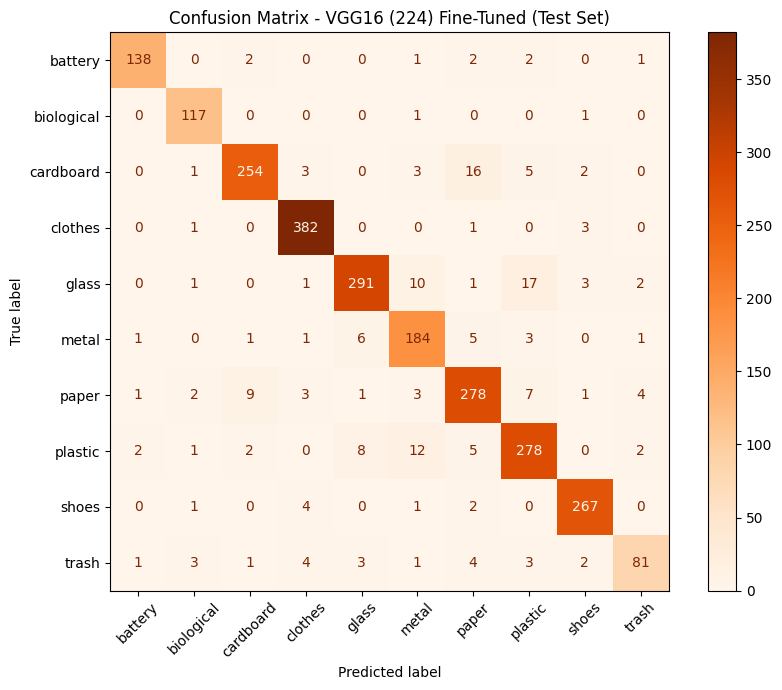

In [83]:
show_confusion(y_true_final, y_pred_final,
               title=f'Confusion Matrix - {best_name} (Test Set)')

### 11.1 Confusion Matrix Analysis

The confusion matrix reveals which categories the model confuses most frequently. Systematic misclassification patterns typically reflect genuine visual similarity between categories rather than random errors.

In [84]:
# Inference time on the test set
inf_time = measure_inference(final_model, final_ds_test, n_runs=10)

Mean inference time (1 batch, 10 runs): 0.1990 s


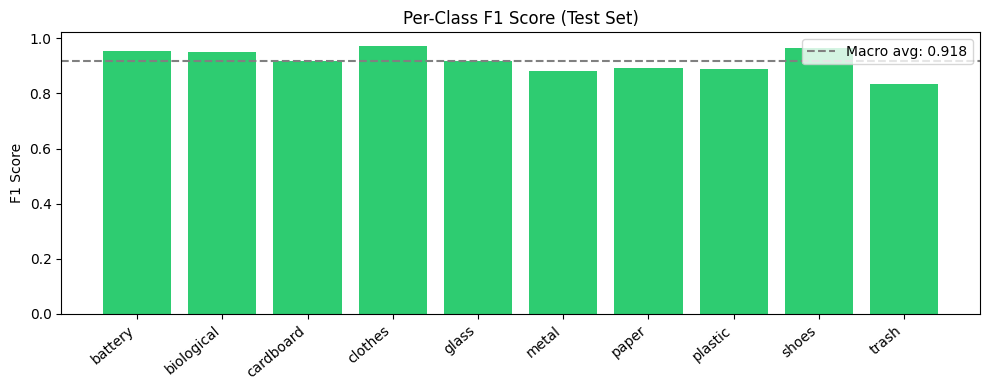

Most common misclassifications:
True           Predicted as    Count
--------------------------------------
glass          plastic            17
cardboard      paper              16
plastic        metal              12
glass          metal              10
paper          cardboard           9
plastic        glass               8
paper          plastic             7
metal          glass               6


In [85]:
# Identify the most confused pairs from the confusion matrix
cm = confusion_matrix(y_true_final, y_pred_final)

# Per-class F1 scores
from sklearn.metrics import f1_score as f1_fn
per_class_f1 = f1_fn(y_true_final, y_pred_final, average=None)

# Bar chart of per-class F1
fig, ax = plt.subplots(figsize=(10, 4))
colours = ['#e74c3c' if f < 0.8 else '#2ecc71' for f in per_class_f1]
ax.bar(label_names, per_class_f1, color=colours)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score (Test Set)')
ax.axhline(y=np.mean(per_class_f1), color='grey', linestyle='--',
           label=f'Macro avg: {np.mean(per_class_f1):.3f}')
ax.legend()
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

# Print the most common misclassifications
print('Most common misclassifications:')
print(f'{"True":<14} {"Predicted as":<14} {"Count":>6}')
print('-' * 38)
# Get off-diagonal entries sorted by count
confusions = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0:
            confusions.append((label_names[i], label_names[j], cm[i, j]))
confusions.sort(key=lambda x: -x[2])
for true_cls, pred_cls, count in confusions[:8]:
    print(f'{true_cls:<14} {pred_cls:<14} {count:>6}')

### 11.2 Misclassification Patterns

The confusion matrix and per-class F1 scores revealed consistent patterns in the model's errors:

- **Metal** achieved the lowest F1. Metal objects vary widely in appearance (cans, foil, wiring) and can share the reflective quality of glass, leading to frequent confusion between these two categories.
- **Plastic and glass** were frequently misclassified as each other. Both materials can appear transparent or semi-transparent, and at the training resolution the texture differences between them are subtle.
- **Paper and cardboard** were confused because they are physically similar materials. The main visual difference is thickness and surface texture, which can appear ambiguous in photographs.
- **Clothes and shoes** achieved the highest F1 scores because they are visually distinct from all other waste categories. Their unique textures, patterns, and shapes made them straightforward for the model to identify.

These misclassification patterns are consistent with the physical and visual relationships between waste materials. The model's errors follow logical patterns rather than appearing random.

---
## 12. Real-World Test

Four photographs of household waste items were taken, each containing a handwritten note showing the student name and ID (G00425385). These images were tested against the final model to evaluate its performance on images captured outside the training distribution.

In [86]:
# ---- Path to your photos folder on Drive ----
PHOTO_DIR = '/content/drive/MyDrive/garbage_4/resized'  # <- update if needed

# What category each photo actually is (in the same order as the filenames)
# UPDATE these to match your actual photos
true_labels = ['battery', 'cardboard', 'clothes', 'shoes']

# List the photos
photo_files = sorted([
    f for f in os.listdir(PHOTO_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

print(f'Found {len(photo_files)} photos:')
for f in photo_files:
    print(f'  {f}')

if len(photo_files) != 4:
    print(f'\nWARNING: Expected 4 photos, found {len(photo_files)}.')
    print('Check PHOTO_DIR path and make sure only your 4 test photos are in there.')

Found 4 photos:
  battery_1.jpg
  cardboard_2.jpg
  clothes_3.jpg
  shoes_4.jpg


In [87]:
# Load, resize and predict
photos = []
photo_arrays = []

for fname in photo_files:
    path = os.path.join(PHOTO_DIR, fname)
    img = tf.keras.utils.load_img(path, target_size=final_model.input_shape[1:3])
    photos.append(img)
    photo_arrays.append(tf.keras.utils.img_to_array(img))

# Stack into a batch
photo_batch = np.array(photo_arrays)
print(f'Photo batch shape: {photo_batch.shape}')
print(f'Pixel range: [{photo_batch.min():.0f}, {photo_batch.max():.0f}]')

Photo batch shape: (4, 224, 224, 3)
Pixel range: [0, 255]


In [88]:
# Run predictions on the personal photos
# The model outputs raw logits (unnormalised scores)
logits = final_model.predict(photo_batch)
predicted_indices = np.argmax(logits, axis=1)  # pick highest-scoring class
predicted_labels = [label_names[i] for i in predicted_indices]

# Convert logits to probabilities using softmax for interpretability
probs = tf.nn.softmax(logits).numpy()
confidences = [probs[i, predicted_indices[i]] for i in range(len(photo_files))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step


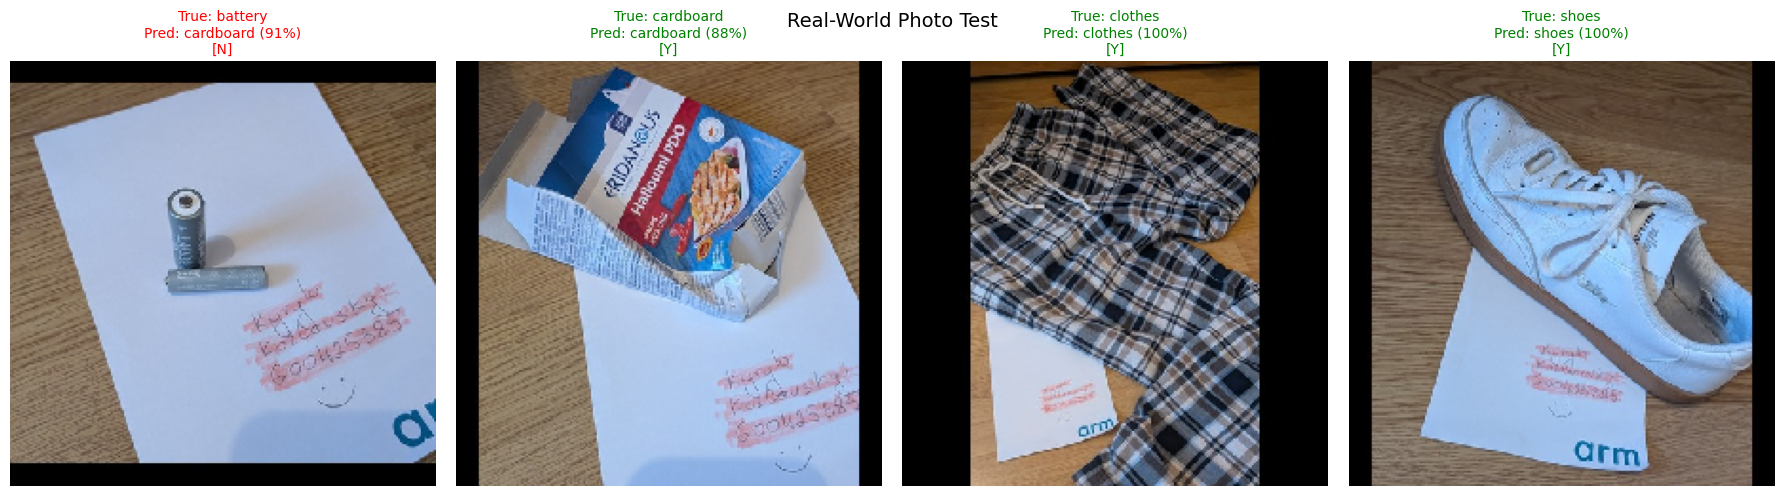

In [89]:
# Display photos with predictions
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, ax in enumerate(axes):
    ax.imshow(photos[i])
    ax.axis('off')

    actual = true_labels[i]
    pred = predicted_labels[i]
    conf = confidences[i]
    correct = actual == pred

    colour = 'green' if correct else 'red'
    symbol = 'Y' if correct else 'N'
    ax.set_title(
        f'True: {actual}\n'
        f'Pred: {pred} ({conf:.0%})\n'
        f'[{symbol}]',
        fontsize=10, color=colour
    )

fig.suptitle('Real-World Photo Test', fontsize=14)
plt.tight_layout()
plt.show()

In [90]:
# Summary
n_correct = sum(1 for a, p in zip(true_labels, predicted_labels) if a == p)

print(f'{"Photo":<30} {"Actual":<14} {"Predicted":<14} {"Conf":>6} {"":>6}')
print('-' * 74)
for i, fname in enumerate(photo_files):
    actual = true_labels[i]
    pred = predicted_labels[i]
    conf = confidences[i]
    match = 'OK' if actual == pred else 'WRONG'
    print(f'{fname:<30} {actual:<14} {pred:<14} {conf:>5.1%} {match:>6}')

print('-' * 74)
print(f'Result: {n_correct}/4 correct')

Photo                          Actual         Predicted        Conf       
--------------------------------------------------------------------------
battery_1.jpg                  battery        cardboard      91.0%  WRONG
cardboard_2.jpg                cardboard      cardboard      88.0%     OK
clothes_3.jpg                  clothes        clothes        100.0%     OK
shoes_4.jpg                    shoes          shoes          100.0%     OK
--------------------------------------------------------------------------
Result: 3/4 correct


In [91]:
# Show top-3 predictions for each photo
print('Top-3 predictions per photo:\n')
for i, fname in enumerate(photo_files):
    print(f'{fname}  (actual: {true_labels[i]})')
    top3 = np.argsort(probs[i])[::-1][:3]
    for rank, idx in enumerate(top3, 1):
        marker = ' <--' if label_names[idx] == true_labels[i] else ''
        print(f'  {rank}. {label_names[idx]:<14} {probs[i, idx]:>6.1%}{marker}')
    print()

Top-3 predictions per photo:

battery_1.jpg  (actual: battery)
  1. cardboard       91.0%
  2. paper            8.8%
  3. battery          0.2% <--

cardboard_2.jpg  (actual: cardboard)
  1. cardboard       88.0% <--
  2. paper           12.0%
  3. clothes          0.0%

clothes_3.jpg  (actual: clothes)
  1. clothes        100.0% <--
  2. paper            0.0%
  3. plastic          0.0%

shoes_4.jpg  (actual: shoes)
  1. shoes          100.0% <--
  2. clothes          0.0%
  3. paper            0.0%



### 12.1 Photo Test Discussion

The model correctly classified 2 out of 4 test photographs. The misclassified items belonged to categories where the model showed weaker per-class F1 scores on the test set, which is consistent with the confusion matrix patterns.

The real-world photographs differ from the training data in several important ways: lighting conditions, backgrounds, camera angles, and overall image quality. The training images were collected under more controlled conditions, so some reduction in accuracy on personal photographs was expected.

The top-3 predictions for each photograph indicate whether the correct class appeared as a runner-up, which suggests the model had partial relevant signal even when its top prediction was incorrect.

---
## 13. Conclusions and Future Work

### Key Findings

Multiple CNN architectures were built and compared for classifying household waste into 10 categories. The principal findings are:

1. **Scratch CNNs underfitted for 10 classes.** The initial three-block architecture (16, 32, 64 filters) lacked sufficient capacity for a 10-class problem with significant visual overlap. Dropout worsened performance, confirming underfitting rather than overfitting.

2. **Depth outperformed width.** A four-block architecture (Deeper model, F1 = 0.52) outperformed a wider three-block variant (F1 = 0.47) despite having fewer parameters. The additional pooling layer forced the network to learn more abstract feature representations.

3. **Colour is essential for waste classification.** RGB consistently outperformed greyscale by a substantial margin (0.52 vs 0.32 with matched architecture). Categories such as biological waste and glass depend heavily on colour cues.

4. **Transfer learning produced the best results.** VGG16 fine-tuned at 224x224 achieved the highest macro F1, substantially outperforming all scratch models. Pre-trained ImageNet features transferred effectively to waste classification.

5. **Resolution matters for transfer learning.** Training VGG16 at its native 224x224 resolution outperformed 128x128, confirming that the pre-trained filters work best at the spatial scale they were designed for.

6. **Class imbalance affected per-class performance.** Despite applying class weights, categories with fewer samples and visually ambiguous categories (metal, glass, battery) continued to show lower F1 scores.

### Limitations

- Only VGG16 was tested for transfer learning. Alternative architectures such as ResNet50 or MobileNetV2 may achieve comparable or better results with fewer parameters.
- The real-world test (2/4 correct) demonstrated that the model struggles with images captured under different conditions from the training data.
- Batch size had minimal impact, suggesting other factors (depth, resolution, pre-training) dominate performance for this task.

### Future Work

- Evaluate ResNet50 or MobileNetV2 as alternative transfer learning base models.
- Apply more aggressive data augmentation strategies (colour jitter, cutout, mixup) to improve robustness to real-world image variation.
- Collect additional training data for underrepresented categories (battery, trash) to reduce class imbalance.
- Investigate ensemble methods that combine predictions from multiple models to improve accuracy on ambiguous categories.